In [1]:
%load_ext autoreload
%autoreload 2


### Download daily SPY and VIX prices

This notebook builds the regime-dependent VRP analysis incrementally; each step adds one block of logic and prints a sanity check before the next is added. The next code cell downloads daily closing prices for SPY and the VIX index from Yahoo Finance, starting from the configured sample start at SPY inception (1993-01-29) through today. SPY is used as the S&P 500 proxy because it is directly tradable, which anchors the realised volatility construction to a real instrument rather than to a paper index. The output should show two DataFrames with a tz-naive DatetimeIndex, no missing values in the close column, end dates within the last week, and several thousand daily rows for SPY and a similar order of magnitude for VIX.

In [2]:
import sys
from pathlib import Path

# Walk up from the notebook's working directory until we find the /src package,
# then put the project root on sys.path so `from src import ...` works whether
# Jupyter was launched from the project root or from /notebooks.
_p = Path.cwd().resolve()
while not (_p / "src" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
PROJECT_ROOT = _p
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data_loader import download_prices

spy = download_prices(config.TICKER_SPY)
vix = download_prices(config.TICKER_VIX)

for name, df in [(config.TICKER_SPY, spy), (config.TICKER_VIX, vix)]:
    print(f"======== {name} ========")
    print(f"shape:       {df.shape}")
    print(f"index dtype: {df.index.dtype}")
    print(f"first date:  {df.index.min().date()}")
    print(f"last date:   {df.index.max().date()}")
    print("head(3):")
    print(df.head(3))
    print("tail(3):")
    print(df.tail(3))
    print()

======== SPY ========
shape:       (8403, 1)
index dtype: datetime64[s]
first date:  1993-01-29
last date:   2026-06-17
head(3):
               close
date                
1993-01-29  43.93750
1993-02-01  44.25000
1993-02-02  44.34375
tail(3):
                 close
date                  
2026-06-15  754.830017
2026-06-16  750.330017
2026-06-17  750.549988

======== ^VIX ========
shape:       (8404, 1)
index dtype: datetime64[s]
first date:  1993-01-29
last date:   2026-06-17
head(3):
            close
date             
1993-01-29  12.42
1993-02-01  12.33
1993-02-02  12.25
tail(3):
                close
date                 
2026-06-15  16.200001
2026-06-16  16.410000
2026-06-17  16.809999



### Snapshot raw data for reproducibility

The raw daily closes for SPY, VIX, and ^SKEW are frozen to the parquet named by `config.LOCKED_SNAPSHOT_DATE` in `data/`. Every run reads from that specific file by default; `download_prices` never performs a live pull unless `REFRESH_SNAPSHOT = True` is set explicitly in the code cell below.

The four ^SKEW data gaps (2023-07-03, 2023-10-02, 2024-08-01, 2024-10-01) are preserved in the snapshot as-is and must not be filled, because they determine the final 388-row dataset.

To update the sample to a later date: (1) set `REFRESH_SNAPSHOT = True` in the cell below and run it once; (2) update `config.LOCKED_SNAPSHOT_DATE` to the new date; (3) delete the old snapshot files; (4) re-run all results cells and validate the new baseline numbers.

In [3]:
import pandas as pd

# Locked-snapshot verification
# Set REFRESH_SNAPSHOT = True ONLY when intentionally updating the sample to a
# new date. After that: update config.LOCKED_SNAPSHOT_DATE, delete old snapshot
# files, and re-run all results cells. Never True on a plain run-all.
REFRESH_SNAPSHOT = False

snap_path = config.DATA_DIR / f"{config.SNAPSHOT_PREFIX}{config.LOCKED_SNAPSHOT_DATE}.parquet"

if REFRESH_SNAPSHOT:
    spy_snap  = download_prices(config.TICKER_SPY,  refresh=True)
    vix_snap  = download_prices(config.TICKER_VIX,  refresh=True)
    skew_snap = download_prices(config.TICKER_SKEW, refresh=True)
    print(f"Snapshot written: {snap_path.name}")
    snapshot_rows = []
    for ticker, df in [
        (config.TICKER_SPY,  spy_snap),
        (config.TICKER_VIX,  vix_snap),
        (config.TICKER_SKEW, skew_snap),
    ]:
        snapshot_rows.append({"ticker": ticker, "rows": len(df),
                              "start": df.index.min().date(), "end": df.index.max().date()})
    display(pd.DataFrame(snapshot_rows))
else:
    if not snap_path.exists():
        raise FileNotFoundError(
            f"Locked snapshot not found: {snap_path}\n"
            f"Set REFRESH_SNAPSHOT = True to fetch from yfinance and write it."
        )
    snap_df = pd.read_parquet(snap_path)
    print(f"Locked snapshot confirmed: {snap_path.name}")
    print(f"  config.LOCKED_SNAPSHOT_DATE: {config.LOCKED_SNAPSHOT_DATE}")
    print(f"  Columns: {list(snap_df.columns)}")
    print(f"  Rows:    {len(snap_df)}")
    print(f"  Dates:   {snap_df.index.min().date()} to {snap_df.index.max().date()}")
    snapshot_rows = []
    for key in [config.TICKER_SPY.lstrip("^"), config.TICKER_VIX.lstrip("^"), config.TICKER_SKEW.lstrip("^")]:
        col = snap_df[key].dropna()
        snapshot_rows.append({"series": key, "rows": len(col),
                              "start": col.index.min().date(), "end": col.index.max().date()})
    display(pd.DataFrame(snapshot_rows))

Locked snapshot confirmed: raw_snapshot_2026-06-17.parquet
  config.LOCKED_SNAPSHOT_DATE: 2026-06-17
  Columns: ['SPY', 'VIX', 'SKEW']
  Rows:    8404
  Dates:   1993-01-29 to 2026-06-17


,series,rows,start,end
0,SPY,8403,1993-01-29,2026-06-17
1,VIX,8404,1993-01-29,2026-06-17
2,SKEW,8328,1993-01-29,2026-06-16


### Compute daily log-returns

The next cell computes daily log-returns from SPY closing prices using the formula ln(P_t / P_{t-1}), where P_t is the adjusted close on day t. The first row is dropped because the differencing operation produces no valid return for the initial observation. The output should show a Series of length equal to len(spy) minus one, with a DatetimeIndex that begins on 1993-02-01, the first day for which a prior close exists, and ends on the same final date as the raw SPY data.

In [4]:
from src.returns import compute_log_returns

spy_returns = compute_log_returns(spy)

print(f'shape:      {spy_returns.shape}')
print(f'first date: {spy_returns.index.min().date()}')
print(f'last date:  {spy_returns.index.max().date()}')
print('head(3):')
print(spy_returns.head(3))
print('tail(3):')
print(spy_returns.tail(3))
print(f'length check (len(spy_returns) == len(spy) - 1): {len(spy_returns) == len(spy) - 1}')

shape:      (8402,)
first date: 1993-02-01
last date:  2026-06-17
head(3):
date
1993-02-01    0.007087
1993-02-02    0.002116
1993-02-03    0.010515
Name: log_return, dtype: float64
tail(3):
date
2026-06-15    0.017480
2026-06-16   -0.005979
2026-06-17    0.000293
Name: log_return, dtype: float64
length check (len(spy_returns) == len(spy) - 1): True


### Rolling 21-day realised volatility

The next cell computes the 21-day rolling realised volatility (RV) from SPY log-returns, annualised by multiplying the rolling standard deviation by sqrt(252) and scaled by 100 so the units match VIX (both series are in annualised volatility points, e.g. 16.99 means 16.99 percent per year). The first 20 daily observations are dropped because a 21-day window cannot be filled until day 21. The output should show a Series whose length equals len(spy_returns) minus 20, with values typically between 5 and 80, and a recent mean that is plausibly close to, though generally below, the current VIX level.

In [5]:
from src.realised_vol import compute_realised_vol

spy_rv = compute_realised_vol(spy_returns)

print(f'shape:      {spy_rv.shape}')
print(f'first date: {spy_rv.index.min().date()}')
print(f'last date:  {spy_rv.index.max().date()}')
print('head(3):')
print(spy_rv.head(3))
print('tail(3):')
print(spy_rv.tail(3))
print('\nsummary stats:')
print(f'  min:    {spy_rv.min():.2f}')
print(f'  mean:   {spy_rv.mean():.2f}')
print(f'  median: {spy_rv.median():.2f}')
print(f'  max:    {spy_rv.max():.2f}')
print(f'\nmean RV last 21 days: {spy_rv.tail(21).mean():.2f}  |  current VIX: {vix["close"].iloc[-1]:.2f}')


shape:      (8382,)
first date: 1993-03-02
last date:  2026-06-17
head(3):
date
1993-03-02    13.124567
1993-03-03    12.994158
1993-03-04    13.176579
Name: rv, dtype: float64
tail(3):
date
2026-06-15    16.005843
2026-06-16    15.535806
2026-06-17    15.528184
Name: rv, dtype: float64

summary stats:
  min:    3.47
  mean:   15.90
  median: 13.40
  max:    94.00

mean RV last 21 days: 11.91  |  current VIX: 16.81


### HAR-RV one-step-ahead variance forecasts

The next cell calls fit_har_rv_forecast at three specific dates to verify that the recursive HAR-RV forecaster produces plausible E_t[RV^2(t+1)] values before it is used across the full monthly date range in T15. The forecaster refits an OLS regression of the 21-day-ahead realised variance on HAR regressors (1-, 5-, and 22-day rolling means of daily squared returns) at each date using only data available on or before that date. Each forecast should be a strictly positive annualised variance below 1.0, with the value for 2005 reflecting a low-volatility post-crisis-recovery environment, 2015 a normal regime, and 2025 a recent low-volatility period.

In [6]:
from src.har_rv import fit_har_rv_forecast

har_rv_spot_checks = fit_har_rv_forecast(
    spy_returns,
    ["2005-01-03", "2015-01-02", "2025-01-02"],
)

print("HAR-RV one-step-ahead variance forecasts (annualised variance):")
print(har_rv_spot_checks)

for _t, _v in har_rv_spot_checks.items():
    assert _v > 0, f"negative forecast at {_t.date()}: {_v}"
    assert _v < 1.0, f"implausibly large forecast at {_t.date()}: {_v}"



HAR-RV one-step-ahead variance forecasts (annualised variance):
2005-01-03    0.018115
2015-01-02    0.022796
2025-01-02    0.023623
Name: har_rv_forecast, dtype: float64


### Canonical Bekaert-Hoerova VRP series

The next cell constructs VRP(t) = VIX^2(t)/10000 - E_t[RV^2(t+1)], where VIX^2(t)/10000 converts the VIX level from vol-points to decimal annualised variance and E_t[RV^2(t+1)] is the recursive HAR-RV forecast from T14. Both terms are in annualised decimal variance units. The mean VRP should be positive and most months should show a positive value, consistent with the finding that implied variance exceeds subsequent realised variance on average.

shape:      (398,)
first date: 1993-05-03
last date:  2026-06-01

head(3):
1993-05-03    0.003737
1993-06-01    0.008348
1993-07-01    0.001910
Name: vrp, dtype: float64

tail(3):
2026-04-01    0.015792
2026-05-01    0.006837
2026-06-01    0.006084
Name: vrp, dtype: float64

describe():
count    398.000000
mean       0.011623
std        0.025882
min       -0.299033
25%       -0.000002
50%        0.007664
75%        0.018202
max        0.139879
Name: vrp, dtype: float64

negative-VRP months: 100 of 398 (25.1%)


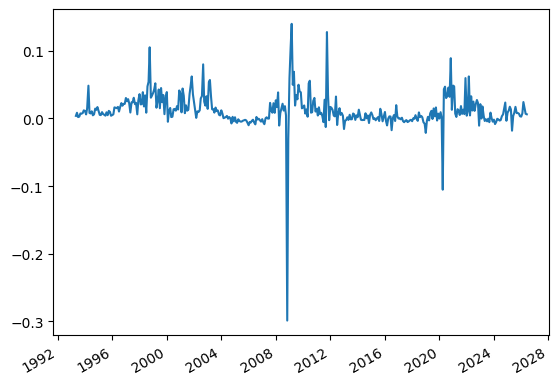

In [7]:
import matplotlib.pyplot as plt
from src.vrp import build_vrp_series, resample_to_month_start

vix_monthly = resample_to_month_start(vix["close"])
forecast_dates = vix_monthly.index

vrp = build_vrp_series(vix_monthly, spy_returns, forecast_dates)

print(f"shape:      {vrp.shape}")
print(f"first date: {vrp.index.min().date()}")
print(f"last date:  {vrp.index.max().date()}")
print("\nhead(3):")
print(vrp.head(3))
print("\ntail(3):")
print(vrp.tail(3))
print("\ndescribe():")
print(vrp.describe())

neg_count = (vrp < 0).sum()
print(f"\nnegative-VRP months: {neg_count} of {len(vrp)} ({100 * neg_count / len(vrp):.1f}%)")

vrp.plot()
plt.show()

### Monthly base frame

Every feature in the locked feature set is indexed on the same monthly first-trading-day dates as the canonical VRP series. This cell creates the base DataFrame `monthly` that downstream feature cells extend column by column. Anchoring the index directly on `vrp.index` ensures that no secondary resample or date-alignment step can introduce a one-period offset or a phantom missing row.

`vix_level` is produced by `vix_monthly.reindex(vrp.index)`, which is the same operation used inside `build_feature_matrix` (src/features.py). `vix_monthly` itself is `resample_to_month_start(vix["close"])`, already computed in the VRP cell above. There is therefore a single source for monthly VIX across the notebook and the production pipeline.

In [8]:
import pandas as pd

monthly = pd.DataFrame({"vrp": vrp, "vix_level": vix_monthly.reindex(vrp.index)})

print(f"shape:       {monthly.shape}")
print(f"index dtype: {monthly.index.dtype}")
print("\nhead(3):")
print(monthly.head(3))
print("\ntail(3):")
print(monthly.tail(3))

assert monthly.index.equals(vrp.index), "monthly.index does not match vrp.index"
assert monthly["vix_level"].notna().all(), "NaN in vix_level"
print("\nmonthly.index.equals(vrp.index): True")
print(f"vix_level NaN count: {monthly['vix_level'].isna().sum()}")

shape:       (398, 2)
index dtype: datetime64[s]

head(3):
                 vrp  vix_level
1993-05-03  0.003737      12.90
1993-06-01  0.008348      13.67
1993-07-01  0.001910      11.51

tail(3):
                 vrp  vix_level
2026-04-01  0.015792  24.540001
2026-05-01  0.006837  16.990000
2026-06-01  0.006084  16.049999

monthly.index.equals(vrp.index): True
vix_level NaN count: 0


### Regime classification

VIX regimes partition the sample into three market states (calm, normal, stressed) using the thresholds in config. The classifier is pointwise: regime at month t depends only on VIX at t, so there is no lookahead. Attaching it to `monthly` here makes it available to every downstream feature cell and to the final assemble check.

`label_regimes` applies `classify_regime` element-wise and returns a categorical Series with categories ordered as `config.REGIME_LABELS`. Passing `monthly["vix_level"]` directly reuses the same already-aligned monthly VIX column, so no second resample is needed.

In [9]:
from src.regimes import label_regimes

monthly["regime"] = label_regimes(monthly["vix_level"])

print("head(3):")
print(monthly.head(3))
print("\nregime value_counts:")
print(monthly["regime"].value_counts())
print(f"\nregime dtype:      {monthly['regime'].dtype}")
print(f"categories:        {list(monthly['regime'].cat.categories)}")
print(f"config.REGIME_LABELS: {list(config.REGIME_LABELS)}")

assert monthly["regime"].isna().sum() == 0, "NaN in regime"
assert list(monthly["regime"].cat.categories) == list(config.REGIME_LABELS), "category mismatch"
print("\nregime NaN count: 0")
print("categories match config.REGIME_LABELS: True")

head(3):
                 vrp  vix_level regime
1993-05-03  0.003737      12.90   calm
1993-06-01  0.008348      13.67   calm
1993-07-01  0.001910      11.51   calm

regime value_counts:
regime
normal      199
calm        128
stressed     71
Name: count, dtype: int64

regime dtype:      category
categories:        ['calm', 'normal', 'stressed']
config.REGIME_LABELS: ['calm', 'normal', 'stressed']

regime NaN count: 0
categories match config.REGIME_LABELS: True


### CBOE SKEW feature

`cboe_skew` is the CBOE SKEW index level at the first available trading day of each calendar month. It measures implied left-tail risk from S&P 500 options and is the locked tail-risk predictor in the feature set. `build_feature_matrix` assigns it by reindexing `skew_monthly` onto the monthly index, identically to `vix_level`. The notebook reads `^SKEW` from the locked snapshot, resamples with `resample_to_month_start`, and keeps `skew_monthly` in scope for the assemble cell. The output should show SKEW coverage from 1993 and list any first-trading-day gaps, which are preserved and later removed by the assemble step's `dropna`.

In [10]:
skew = download_prices(config.TICKER_SKEW)

print(f"SKEW first date: {skew.index.min().date()}")
print(f"SKEW last date:  {skew.index.max().date()}")
print(f"SKEW shape:      {skew.shape}")

if skew.index.min() > pd.Timestamp("1993-12-31"):
    raise RuntimeError(
        f"SKEW starts {skew.index.min().date()}, after 1993. "
        "Do not truncate or backfill; investigate the data source."
    )

skew_monthly = resample_to_month_start(skew["close"])
monthly["cboe_skew"] = skew_monthly.reindex(monthly.index)

print("\ndescribe():")
print(monthly[["cboe_skew"]].describe())
print("\nhead(3):")
print(monthly[["cboe_skew"]].head(3))
print("\ntail(3):")
print(monthly[["cboe_skew"]].tail(3))

nan_count = monthly["cboe_skew"].isna().sum()
print(f"\nNaN count: {nan_count}")
if nan_count > 0:
    nan_dates = monthly.index[monthly["cboe_skew"].isna()]
    print(f"NaN dates (^SKEW missing from yfinance on these first-trading-days):")
    for d in nan_dates:
        print(f"  {d.date()}")
    print("These rows will be dropped by dropna() in the assemble cell.")
else:
    print("cboe_skew NaN count: 0")

SKEW first date: 1993-01-29
SKEW last date:  2026-06-16
SKEW shape:      (8328, 1)

describe():
        cboe_skew
count  394.000000
mean   123.407056
std     11.482478
min    104.889999
25%    115.472502
50%    119.915001
75%    128.185001
max    170.649994

head(3):
             cboe_skew
1993-05-03  112.110001
1993-06-01  120.769997
1993-07-01  109.139999

tail(3):
             cboe_skew
2026-04-01  143.770004
2026-05-01  141.380005
2026-06-01  142.460007

NaN count: 4
NaN dates (^SKEW missing from yfinance on these first-trading-days):
  2023-07-03
  2023-10-02
  2024-08-01
  2024-10-01
These rows will be dropped by dropna() in the assemble cell.


### Realised skewness feature

`realised_skew_21d` is the adjusted Fisher-Pearson skewness (`scipy.stats.skew(bias=False)`) of the trailing `config.RV_WINDOW` daily SPY log-returns at each monthly first-trading-day date. It captures the shape of the recent return distribution, particularly left-tail risk. The window ends at and includes the monthly date t, so the computation is strictly backward-looking. The notebook calls the same `compute_realised_skew_21d` the production builder uses, with `monthly.index` as the evaluation dates, and recomputes one interior date by hand as a check.

In [11]:
from src.features import compute_realised_skew_21d
from scipy.stats import skew as scipy_skew

monthly["realised_skew_21d"] = compute_realised_skew_21d(spy_returns, monthly.index)

print("describe():")
print(monthly[["realised_skew_21d"]].describe())
print(f"\nNaN count: {monthly['realised_skew_21d'].isna().sum()}")
print("\nhead(8):")
print(monthly[["realised_skew_21d"]].head(8))

# Manual recomputation on one interior date: trailing config.RV_WINDOW returns
# ending at t, scipy.stats.skew(bias=False), same definition as the function.
t = monthly.index[50]
window_returns = spy_returns.loc[spy_returns.index <= t].iloc[-config.RV_WINDOW:]
manual = float(scipy_skew(window_returns.values, bias=False))
got = monthly["realised_skew_21d"].loc[t]
print(f"\nManual check at {t.date()} (row 50):")
print(f"  monthly value:   {got:.8f}")
print(f"  scipy recompute: {manual:.8f}")
print(f"  match: {abs(got - manual) < 1e-10}")
assert abs(got - manual) < 1e-10, "realised_skew_21d mismatch"

describe():
       realised_skew_21d
count         398.000000
mean           -0.097355
std             0.615431
min            -3.180844
25%            -0.522358
50%            -0.071101
75%             0.313763
max             1.575305

NaN count: 0

head(8):
            realised_skew_21d
1993-05-03          -0.640619
1993-06-01           0.590014
1993-07-01           0.050293
1993-08-02          -0.006170
1993-09-01           1.197771
1993-10-01           0.580303
1993-11-01           0.934712
1993-12-01          -0.747101

Manual check at 1997-07-01 (row 50):
  monthly value:   -0.03793959
  scipy recompute: -0.03793959
  match: True


### VRP horizon features

The three VRP predictor columns are named by horizon to the target, not by lag from t. On a row whose target is VRP(t+1), `vrp_h1m` carries VRP(t), `vrp_h3m` carries VRP(t-2), and `vrp_h6m` carries VRP(t-5), so the number in each name is the distance in months from that column to the target on the same row. The next cell builds the full 7-column locked feature matrix with `build_feature_matrix`, the same /src builder the model-ready assembler wraps, so no notebook-local shift arithmetic exists to drift from the pipeline. The spot check reads positions directly off the raw `vrp` series and asserts each horizon column carries the VRP value at its named distance; the nearest predictor is VRP(t) itself, one step from the target, which the target-verification cell confirms against `y`.

In [12]:
from src.features import build_feature_matrix
from src.validation import VRP_HORIZON_COLS

features = build_feature_matrix(vrp, vix_monthly, skew_monthly, spy_returns, monthly["regime"])

print(f"features shape: {features.shape}  (7 locked columns on vrp.index)")
print("head(8): warm-up NaN rows for the deepest horizon column:")
print(features[list(VRP_HORIZON_COLS)].head(8))
print()

# Positional spot check: horizon column k carries the VRP observation k-1 steps
# behind t, so it sits k steps from the target at t+1. Read straight off vrp.
for t in [features.index[25], features.index[60]]:
    p = vrp.index.get_loc(t)
    for k, col in zip(config.HAR_LAGS_MONTHS, VRP_HORIZON_COLS):
        got = features.at[t, col]
        expected = vrp.iloc[p - (k - 1)]
        assert got == expected, f"{col} at {t.date()}: {got} != {expected}"
    sources = ", ".join(str(p - (k - 1)) for k in config.HAR_LAGS_MONTHS)
    print(f"{t.date()} (position {p}): horizon columns carry vrp positions {sources}  OK")

n_warmup = max(config.HAR_LAGS_MONTHS) - 1
n_nan_rows = int(features[list(VRP_HORIZON_COLS)].isna().any(axis=1).sum())
print(f"\nwarm-up rows with a NaN horizon column: {n_nan_rows} "
      f"(expected {n_warmup}: deepest shift is max(HAR_LAGS_MONTHS) - 1)")
assert n_nan_rows == n_warmup

features shape: (398, 7)  (7 locked columns on vrp.index)
head(8): warm-up NaN rows for the deepest horizon column:
             vrp_h1m   vrp_h3m   vrp_h6m
1993-05-03  0.003737       NaN       NaN
1993-06-01  0.008348       NaN       NaN
1993-07-01  0.001910  0.003737       NaN
1993-08-02  0.002651  0.008348       NaN
1993-09-01  0.007351  0.001910       NaN
1993-10-01  0.007048  0.002651  0.003737
1993-11-01  0.007839  0.007351  0.008348
1993-12-01  0.011939  0.007048  0.001910

1995-06-01 (position 25): horizon columns carry vrp positions 25, 23, 20  OK
1998-05-01 (position 60): horizon columns carry vrp positions 60, 58, 55  OK

warm-up rows with a NaN horizon column: 5 (expected 5: deepest shift is max(HAR_LAGS_MONTHS) - 1)


### Build model-ready dataset and assert-match

This cell assembles the canonical model-ready dataset with `build_model_ready_dataset` and cross-checks every locked feature column against the frames built cell by cell above: the four directly-built columns against `monthly` and all seven against the `features` matrix. If any column mismatches, the cell raises and names the first differing column and date. The `dropna` inside the assembler removes the horizon warm-up rows (`max(HAR_LAGS_MONTHS) - 1` of them, because the deepest shift is one less than the deepest horizon), the four ^SKEW gap rows, and the trailing row with no t+1 target, leaving the 388-row dataset starting 1993-10-01.

In [13]:
from src.dataset import build_model_ready_dataset
from src.validation import LOCKED_FEATURE_SET, assert_feature_set_complete

regime_labels = label_regimes(vix_monthly)

dataset = build_model_ready_dataset(vrp, vix_monthly, skew_monthly, spy_returns, regime_labels)

assert_feature_set_complete(dataset)
print("assert_feature_set_complete: passed\n")
print(f"shape:      {dataset.shape}")
print(f"first date: {dataset.index.min().date()}")
print(f"last date:  {dataset.index.max().date()}")
print("\ndtypes:")
print(dataset.dtypes)
print("\nNaN count per column:")
print(dataset.isna().sum())
print("\nregime value_counts:")
print(dataset["regime"].value_counts())

# Dropped-row reconciliation. The warm-up is max(HAR_LAGS_MONTHS) - 1 rows under
# the horizon convention (deepest shift = deepest horizon - 1).
n_base = len(monthly)
n_lag_warmup = max(config.HAR_LAGS_MONTHS) - 1
n_skew_gaps = int(features["cboe_skew"].isna().sum())
n_trailing = 1
expected_dropped = n_lag_warmup + n_skew_gaps + n_trailing
actual_dropped = n_base - len(dataset)
print(f"\nDropped-row reconciliation:")
print(f"  base monthly rows:            {n_base}")
print(f"  horizon warm-up (max lag -1): {n_lag_warmup}")
print(f"  ^SKEW data gaps:              {n_skew_gaps}")
print(f"  trailing (no t+1 target):     {n_trailing}")
print(f"  expected dropped:             {expected_dropped}")
print(f"  actual dropped:               {actual_dropped}")
assert actual_dropped == expected_dropped, "reconciliation mismatch: unexpected NaN source"
print(f"  reconciled: OK")

# Classify and list dropped dates.
dropped = monthly.index.difference(dataset.index)
skew_gap_set = set(monthly.index[features["cboe_skew"].isna()])
warmup_set = set(monthly.index[:n_lag_warmup])
trailing_set = {monthly.index[-1]}
print(f"\nDropped dates ({len(dropped)}):")
for d in dropped:
    if d in warmup_set:
        reason = "horizon warm-up"
    elif d in skew_gap_set:
        reason = "^SKEW gap"
    elif d in trailing_set:
        reason = "trailing (no y)"
    else:
        reason = "unknown"
    print(f"  {d.date()}  [{reason}]")

# Assert-match: the cell-built frames must equal the assembler's output exactly.
print("\nAssert-match (features matrix and monthly columns vs dataset):")
for col in LOCKED_FEATURE_SET:
    d_vals = dataset[col]
    f_vals = features.loc[dataset.index, col]
    if isinstance(f_vals.dtype, pd.CategoricalDtype):
        mismatch = f_vals.astype(str) != d_vals.astype(str)
    else:
        mismatch = f_vals != d_vals
    if mismatch.any():
        first_bad = dataset.index[mismatch][0]
        raise AssertionError(
            f"DRIFT BUG: '{col}' at {first_bad.date()}: "
            f"features={f_vals.at[first_bad]!r}, dataset={d_vals.at[first_bad]!r}"
        )
    checked = "features"
    if col in monthly.columns:
        m_vals = monthly.loc[dataset.index, col]
        if isinstance(m_vals.dtype, pd.CategoricalDtype):
            m_mismatch = m_vals.astype(str) != d_vals.astype(str)
        else:
            m_mismatch = m_vals != d_vals
        if m_mismatch.any():
            first_bad = dataset.index[m_mismatch][0]
            raise AssertionError(
                f"DRIFT BUG: '{col}' at {first_bad.date()}: "
                f"monthly={m_vals.at[first_bad]!r}, dataset={d_vals.at[first_bad]!r}"
            )
        checked = "features + monthly"
    print(f"  {col}: OK ({checked})")

print("\nhead(3):")
print(dataset.head(3))
print("\ntail(3):")
print(dataset.tail(3))

assert_feature_set_complete: passed

shape:      (388, 8)
first date: 1993-10-01
last date:  2026-05-01

dtypes:
vix_level             float64
cboe_skew             float64
vrp_h1m               float64
vrp_h3m               float64
vrp_h6m               float64
realised_skew_21d     float64
regime               category
y                     float64
dtype: object

NaN count per column:
vix_level            0
cboe_skew            0
vrp_h1m              0
vrp_h3m              0
vrp_h6m              0
realised_skew_21d    0
regime               0
y                    0
dtype: int64

regime value_counts:
regime
normal      195
calm        122
stressed     71
Name: count, dtype: int64

Dropped-row reconciliation:
  base monthly rows:            398
  horizon warm-up (max lag -1): 5
  ^SKEW data gaps:              4
  trailing (no t+1 target):     1
  expected dropped:             10
  actual dropped:               10
  reconciled: OK

Dropped dates (10):
  1993-05-03  [horizon warm-up]
  1

### Target column verification

`y` is the one-month-ahead VRP: y at row t equals vrp at the immediately following monthly date, so the nearest predictor `vrp_h1m` (which carries VRP(t)) sits exactly one step from the target. Leading rows are dropped for the horizon warm-up (`max(HAR_LAGS_MONTHS) - 1` rows) and the single trailing row is dropped because the last vrp date has no t+1 observation. The code asserts the target value and the nearest-predictor distance on two interior dates, then confirms the drop counts.

In [14]:
# Assert the target equals vrp at the next monthly date, and the corrected
# horizon invariant: the nearest predictor on the row is VRP(t), one step from y.
for t in [dataset.index[20], dataset.index[50]]:
    pos = vrp.index.get_loc(t)
    next_t = vrp.index[pos + 1]
    assert abs(dataset.at[t, "y"] - vrp.loc[next_t]) < 1e-12, f"target mismatch at {t.date()}"
    assert dataset.at[t, VRP_HORIZON_COLS[0]] == vrp.loc[t], (
        f"nearest predictor at {t.date()} is not VRP(t)"
    )
    print(f"y at {t.date()} = vrp at {next_t.date()}; {VRP_HORIZON_COLS[0]} = vrp at {t.date()} "
          f"(one step from the target)  OK")

n_leading_dropped = vrp.index.get_loc(dataset.index[0])
n_expected_warmup = max(config.HAR_LAGS_MONTHS) - 1
print(f"\nleading rows dropped (horizon warm-up): {n_leading_dropped} "
      f"(expected {n_expected_warmup})")
assert n_leading_dropped == n_expected_warmup

last_vrp_date = vrp.index[-1]
trailing_dropped = last_vrp_date not in dataset.index
print(f"last vrp date {last_vrp_date.date()} absent from dataset (trailing drop): {trailing_dropped}")
assert trailing_dropped, "last vrp date should be dropped (no t+1 target)"

y at 1995-06-01 = vrp at 1995-07-03; vrp_h1m = vrp at 1995-06-01 (one step from the target)  OK
y at 1997-12-01 = vrp at 1998-01-02; vrp_h1m = vrp at 1997-12-01 (one step from the target)  OK

leading rows dropped (horizon warm-up): 5 (expected 5)
last vrp date 2026-06-01 absent from dataset (trailing drop): True


### Verification block: locked feature set

The verification block is the formal record that `dataset` carries exactly the 7-column locked feature set defined in `src/validation.py`. `LOCKED_FEATURE_SET` is the single source of truth: the block reads from it, not from an independent list. This output is referenced in the methodology chapter as evidence that the feature set is enforced, not assembled ad hoc.

In [15]:
from src.validation import print_verification_block

print_verification_block(dataset, list(LOCKED_FEATURE_SET))

print()
print(f"dataset.shape:         {dataset.shape}")
print(f"target column 'y':     {'present' if 'y' in dataset.columns else 'MISSING'}")
print(f"locked snapshot date:  {config.LOCKED_SNAPSHOT_DATE}")

assert_feature_set_complete(dataset)
print("\nassert_feature_set_complete: passed")

--- VERIFICATION BLOCK ---
Locked feature set (from context.md): ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Features used in this task: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Locked features present in df:
  vix_level: OK
  cboe_skew: OK
  vrp_h1m: OK
  vrp_h3m: OK
  vrp_h6m: OK
  realised_skew_21d: OK
  regime: OK
Locked features absent from feature list (intentional exclusions, e.g. HAR): []
--- END VERIFICATION BLOCK ---

dataset.shape:         (388, 8)
target column 'y':     present
locked snapshot date:  2026-06-17

assert_feature_set_complete: passed


### QLIKE scoring convention sanity demonstration

The QLIKE conversion was fixed on 2026-06-03 to the Bekaert-Hoerova decimal-variance convention. The corrected formula is:

```
implied_variance(t+1) = vix_next**2 / VIX_VARIANCE_SCALE - vrp_forecast
realised_variance(t+1) = rv_next**2 / VIX_VARIANCE_SCALE
QLIKE = sigma2_realised / sigma2_implied - log(sigma2_realised / sigma2_implied) - 1
```

Both `vrp_forecast` and the output are in decimal annualised variance. `VIX_VARIANCE_SCALE` is reused from config. No literal 10000 appears.

The positivity guard raises (never clips) if `implied_variance <= 0`. This is expected to fire occasionally for low-VIX months where the VRP forecast exceeds the risk-neutral variance; such months are excluded explicitly, with their count reported, never silently worked around.

This cell demonstrates the conversion on three synthetic triples with hand-calculable answers and shows the guard-trip raise with its informative message.

In [16]:
import math
from src.evaluation import vrp_forecast_to_variance, rv_to_variance
from src.metrics import qlike

print("=== QLIKE conversion sanity: synthetic triples ===")
print(f"implied_variance = vix_next**2 / {config.VIX_VARIANCE_SCALE} - vrp_forecast")
print()

# Triple 1: vix=20, vrp=0.01, rv=15
# implied = 400/10000 - 0.01 = 0.04 - 0.01 = 0.03
# realised = 225/10000 = 0.0225
# QLIKE = 0.75 - ln(0.75) - 1 approx 0.03768
vix1, vrp1, rv1 = 20.0, 0.01, 15.0
imp1   = vix1**2 / config.VIX_VARIANCE_SCALE - vrp1
real1  = rv1**2 / config.VIX_VARIANCE_SCALE
ratio1 = real1 / imp1
qlike1_hand = ratio1 - math.log(ratio1) - 1

pip_imp1  = vrp_forecast_to_variance([vrp1], [vix1])[0]
pip_real1 = rv_to_variance([rv1])[0]
pip_q1    = qlike([pip_real1], [pip_imp1])

print(f"Triple 1  vix_next={vix1}  vrp_forecast={vrp1}  rv_next={rv1}")
print(f"  implied_variance  : hand={imp1:.6f}   pipeline={pip_imp1:.6f}  match={abs(imp1-pip_imp1)<1e-12}")
print(f"  realised_variance : hand={real1:.6f}  pipeline={pip_real1:.6f} match={abs(real1-pip_real1)<1e-12}")
print(f"  QLIKE             : hand={qlike1_hand:.8f}  pipeline={pip_q1:.8f}  match={abs(qlike1_hand-pip_q1)<1e-10}")
assert abs(imp1-pip_imp1)<1e-12 and abs(real1-pip_real1)<1e-12 and abs(qlike1_hand-pip_q1)<1e-10

# Triple 2: vix=25, vrp=0.02, rv=20
# implied = 625/10000 - 0.02 = 0.0625 - 0.02 = 0.0425
# realised = 400/10000 = 0.04
# QLIKE = (0.04/0.0425) - ln(0.04/0.0425) - 1 approx 0.00180
vix2, vrp2, rv2 = 25.0, 0.02, 20.0
imp2   = vix2**2 / config.VIX_VARIANCE_SCALE - vrp2
real2  = rv2**2 / config.VIX_VARIANCE_SCALE
ratio2 = real2 / imp2
qlike2_hand = ratio2 - math.log(ratio2) - 1

pip_imp2  = vrp_forecast_to_variance([vrp2], [vix2])[0]
pip_real2 = rv_to_variance([rv2])[0]
pip_q2    = qlike([pip_real2], [pip_imp2])

print()
print(f"Triple 2  vix_next={vix2}  vrp_forecast={vrp2}  rv_next={rv2}")
print(f"  implied_variance  : hand={imp2:.6f}   pipeline={pip_imp2:.6f}  match={abs(imp2-pip_imp2)<1e-12}")
print(f"  realised_variance : hand={real2:.6f}  pipeline={pip_real2:.6f} match={abs(real2-pip_real2)<1e-12}")
print(f"  QLIKE             : hand={qlike2_hand:.8f}  pipeline={pip_q2:.8f}  match={abs(qlike2_hand-pip_q2)<1e-10}")
assert abs(imp2-pip_imp2)<1e-12 and abs(real2-pip_real2)<1e-12 and abs(qlike2_hand-pip_q2)<1e-10

# Guard trip: vix=10, vrp=0.015 -> implied = 0.01 - 0.015 = -0.005
print()
print(f"Guard trip  vix_next=10  vrp_forecast=0.015")
print(f"  implied = 100/{config.VIX_VARIANCE_SCALE} - 0.015 = {100/config.VIX_VARIANCE_SCALE - 0.015:.4f}  (<= 0 -> must raise)")
try:
    vrp_forecast_to_variance([0.015], [10.0])
    raise AssertionError("Expected ValueError but no exception raised")
except ValueError as exc:
    print(f"  Raised ValueError: OK")
    print(f"  Message: {exc}")
    assert "vix_next" in str(exc) and "vrp_forecast" in str(exc) and "implied_variance" in str(exc)
    print("  Message contains vix_next, vrp_forecast, implied_variance: OK")

=== QLIKE conversion sanity: synthetic triples ===
implied_variance = vix_next**2 / 10000 - vrp_forecast

Triple 1  vix_next=20.0  vrp_forecast=0.01  rv_next=15.0
  implied_variance  : hand=0.030000   pipeline=0.030000  match=True
  realised_variance : hand=0.022500  pipeline=0.022500 match=True
  QLIKE             : hand=0.03768207  pipeline=0.03768207  match=True

Triple 2  vix_next=25.0  vrp_forecast=0.02  rv_next=20.0
  implied_variance  : hand=0.042500   pipeline=0.042500  match=True
  realised_variance : hand=0.040000  pipeline=0.040000 match=True
  QLIKE             : hand=0.00180109  pipeline=0.00180109  match=True

Guard trip  vix_next=10  vrp_forecast=0.015
  implied = 100/10000 - 0.015 = -0.0050  (<= 0 -> must raise)
  Raised ValueError: OK
  Message: implied_variance must be strictly > 0; invalid at: index 0: vix_next=10.0000, vrp_forecast=0.015000, implied_variance=-0.005000
  Message contains vix_next, vrp_forecast, implied_variance: OK


### Walk-forward constant baseline (predictions only)

Model 1 in the locked forecast sequence: the **constant mean model** predicts the rolling historical mean of VRP observed up to time T for the step T+1. It uses no features; the only information is the expanding window of past y values seen during fit.

The walk-forward engine trains a fresh `ConstantMeanModel` at each step on all rows with index <= train_end, predicts the single next row, and records (y_true, y_pred). The initial training window spans the first `config.INITIAL_TRAINING_YEARS_FULL` calendar years of the dataset (1993-2004); the first OOS prediction is 2005-01.

This cell produces predictions only. Scoring (QLIKE, MSE, DA) and the results-table entry come in the next section.

In [17]:
from src.models.baseline import ConstantMeanModel
from src.walk_forward import walk_forward, make_model_factory_from_class

# Derive initial_train_end from config: last dataset row whose calendar year
# falls within the first INITIAL_TRAINING_YEARS_FULL years of the sample.
# dataset.index[0].year = 1993; 1993 + 12 - 1 = 2004 -> initial window is 1993-11 ... 2004-12.
_last_train_year = dataset.index[0].year + config.INITIAL_TRAINING_YEARS_FULL - 1
initial_train_end = dataset.loc[dataset.index.year <= _last_train_year].index[-1]

model_factory = make_model_factory_from_class(ConstantMeanModel)

wf_constant = walk_forward(
    dataset,
    feature_cols=[],
    model_factory=model_factory,
    initial_train_end=initial_train_end,
    target_col="y",
)

n_oos = len(wf_constant)
oos_start = wf_constant.index[0]
oos_end = wf_constant.index[-1]

print(f"initial_train_end:  {initial_train_end.date()}  (last_train_year={_last_train_year})")
print(f"wf_constant.shape:  {wf_constant.shape}")
print(f"n_oos:              {n_oos}")
print(f"OOS start:          {oos_start.date()}")
print(f"OOS end:            {oos_end.date()}")
print()
print("head(5):")
display(wf_constant.head(5))
print()
print("tail(5):")
display(wf_constant.tail(5))
print()
# Confirm predictions update as the window expands (not a fixed constant across all steps).
print("First 10 y_pred values (should differ across rows as window grows):")
display(wf_constant["y_pred"].head(10).to_frame())
assert wf_constant["y_pred"].nunique() > 1, "predictions are all identical, window not expanding"
_expected_first_oos = dataset.index[dataset.index.get_loc(initial_train_end) + 1]
assert oos_start == _expected_first_oos, (
    f"OOS start {oos_start.date()} != first row after initial_train_end "
    f"({_expected_first_oos.date()})"
)
print()
print(f"Assertions passed: predictions update, OOS starts {oos_start.date()} "
      f"(first row after initial_train_end, derived from config).")

initial_train_end:  2004-12-01  (last_train_year=2004)
wf_constant.shape:  (253, 2)
n_oos:              253
OOS start:          2005-01-03
OOS end:            2026-05-01

head(5):


,y_true,y_pred
2005-01-03,-0.005219,0.019428
2005-02-01,-0.006528,0.019247
2005-03-01,-0.001317,0.019059
2005-04-01,-0.003760,0.018911
2005-05-02,-0.004735,0.018748



tail(5):


,y_true,y_pred
2026-01-02,0.007416,0.011763
2026-02-02,0.024167,0.011752
2026-03-02,0.015792,0.011784
2026-04-01,0.006837,0.011795
2026-05-01,0.006084,0.011782



First 10 y_pred values (should differ across rows as window grows):


,y_pred
2005-01-03,0.019428
2005-02-01,0.019247
2005-03-01,0.019059
2005-04-01,0.018911
2005-05-02,0.018748
2005-06-01,0.018580
2005-07-01,0.018415
2005-08-01,0.018261
2005-09-01,0.018114
2005-10-03,0.017973



Assertions passed: predictions update, OOS starts 2005-01-03 (first row after initial_train_end, derived from config).


### Forecast comparison machinery: DM and CW routing sanity

This cell validates the `compare_models` dispatcher on **controlled synthetic inputs**, not real model comparisons. Its purpose is to confirm:

1. **DM route (non-nested):** a non-registered pair routes to `diebold_mariano`; the cleaner prediction series is identified as preferred.
2. **CW route (nested):** a pair in `NESTED_MODEL_PAIRS` routes to `clark_west`; the result object carries the expected fields.

**Key interface distinction** that must not be mixed up:
- `diebold_mariano` takes per-observation **loss** series (`losses_a`, `losses_b`)
- `clark_west` takes raw **predictions** (`y_true`, `y_pred_a`, `y_pred_b`)

The model name strings passed to `compare_models` are routing keys only. They determine which test is dispatched via `NESTED_MODEL_PAIRS`; the actual data comes from the loss/prediction arrays. No real HAR or XGBoost model runs here.

In [18]:
import numpy as np
from src.metrics import mse_per_obs
from src.forecast_comparison import compare_models, NESTED_MODEL_PAIRS, is_nested

rng = np.random.default_rng(42)

y_true = wf_constant["y_true"].values
pred_clean = wf_constant["y_pred"].values
n = len(y_true)

# Route 1: DM (non-nested)
# Noisy contrast: clean constant-mean prediction + mean-zero Gaussian noise.
# Noise std=0.015 > typical VRP std (~0.008), so the noisy model has clearly
# higher MSE and the DM test should favour the clean series.
noise = rng.normal(0, 0.015, n)
pred_noisy = pred_clean + noise

losses_clean = mse_per_obs(y_true, pred_clean)
losses_noisy = mse_per_obs(y_true, pred_noisy)

# "har" vs "xgboost": neither direction appears in NESTED_MODEL_PAIRS -> DM.
# losses_a = clean (model_a), losses_b = noisy (model_b).
assert not is_nested("har", "xgboost"), "Expected non-nested pair for DM route"

dm_result = compare_models(
    "har", "xgboost",
    losses_a=losses_clean,
    losses_b=losses_noisy,
)

print("=== Route 1: Diebold-Mariano (non-nested) ===")
print(f"  Pair:              ('har', 'xgboost')")
print(f"  is_nested:         {is_nested('har', 'xgboost')}")
print(f"  Dispatched test:   {dm_result.test_type}")
print(f"  Statistic (HLN):   {dm_result.statistic:.4f}")
print(f"  p-value:           {dm_result.p_value:.6f}")
print(f"  Favoured:          {dm_result.favoured}  (model_a=clean, model_b=noisy)")
print(f"  N / hac_lag:       {dm_result.n} / {dm_result.hac_lag}")
print(f"  mean loss_clean:   {losses_clean.mean():.6f}")
print(f"  mean loss_noisy:   {losses_noisy.mean():.6f}")
print()

assert dm_result.test_type == "diebold_mariano", f"Wrong route: {dm_result.test_type}"
assert dm_result.favoured == "model_a", (
    f"Expected clean (model_a) to be favoured; got {dm_result.favoured!r}. "
    f"stat={dm_result.statistic:.4f}, p={dm_result.p_value:.6f}"
)

# Route 2: CW (nested)
# Synthetic "har-like" forecast: constant baseline + 0.3 x lagged forecast error.
# Adding the lagged-error correction is strictly one extra predictor, placing this
# forecast in the "larger model" slot for the ("constant", "har") nested pair.
residuals = y_true - pred_clean
lagged_resid = np.empty_like(residuals)
lagged_resid[0] = 0.0          # no prior residual at first OOS step
lagged_resid[1:] = residuals[:-1]
pred_har_synth = pred_clean + 0.3 * lagged_resid

# ("constant", "har") is in NESTED_MODEL_PAIRS -> CW.
# compare_models identifies "constant" as the smaller model via NESTED_MODEL_PAIRS
# and maps y_pred_a (constant predictions) -> pred_smaller,
#           y_pred_b (har-like predictions) -> pred_larger.
assert is_nested("constant", "har"), "Expected nested pair for CW route"

cw_result = compare_models(
    "constant", "har",
    y_true=y_true,
    y_pred_a=pred_clean,        # constant = smaller (nested inside har)
    y_pred_b=pred_har_synth,    # har-like  = larger
)

print("=== Route 2: Clark-West (nested) ===")
print(f"  Pair:              ('constant', 'har')")
print(f"  is_nested:         {is_nested('constant', 'har')}")
print(f"  Dispatched test:   {cw_result.test_type}")
print(f"  Statistic:         {cw_result.statistic:.4f}")
print(f"  p-value (1-sided): {cw_result.p_value:.6f}")
print(f"  larger_model_wins: {cw_result.larger_model_wins}  (alpha={config.COMPARISON_ALPHA})")
print(f"  N / hac_lag:       {cw_result.n} / {cw_result.hac_lag}")
print()

assert cw_result.test_type == "clark_west", f"Wrong route: {cw_result.test_type}"

print("Routing assertions passed: DM for non-nested ('har','xgboost'), CW for nested ('constant','har').")

=== Route 1: Diebold-Mariano (non-nested) ===
  Pair:              ('har', 'xgboost')
  is_nested:         False
  Dispatched test:   diebold_mariano
  Statistic (HLN):   -4.0275
  p-value:           0.000075
  Favoured:          model_a  (model_a=clean, model_b=noisy)
  N / hac_lag:       253 / 0
  mean loss_clean:   0.000896
  mean loss_noisy:   0.001050

=== Route 2: Clark-West (nested) ===
  Pair:              ('constant', 'har')
  is_nested:         True
  Dispatched test:   clark_west
  Statistic:         3.4950
  p-value (1-sided): 0.000237
  larger_model_wins: True  (alpha=0.05)
  N / hac_lag:       253 / 0

Routing assertions passed: DM for non-nested ('har','xgboost'), CW for nested ('constant','har').


### Score the constant baseline (QLIKE, MSE, DA)

First reportable result and the reference row for all later comparisons. Scoring goes through `src.results.score_walk_forward`, the single shared scorer that owns the variance-space conversion (implied variance = vix_next^2 / VIX_VARIANCE_SCALE - vrp_forecast, positivity-guarded) and the forward realised target (`realised_variance_target` evaluated at t+1, the same estimator the HAR-RV forecaster is trained on; `compute_realised_vol` never enters the QLIKE path). `vix_next` and the realised target are ex-post t+1 quantities passed to the scorer only, never to the model.

MSE and DA are reported on all OOS months; QLIKE on the valid subset, with the two exclusion reasons reported separately and never conflated: guard trips (implied variance non-positive, mostly the constant's unconditional mean exceeding risk-neutral variance in calm months) and the NaN tail (forward realised window past t+1 not fully in sample yet). Both exclusion tables are derived from the scorer's own outputs and their counts are asserted against the scorer's bookkeeping, so no date list is ever hardcoded.

In [19]:
import numpy as np
import pandas as pd
from src.results import score_walk_forward

vix_next = vix_monthly.shift(-1).reindex(wf_constant.index)
constant_result = score_walk_forward(wf_constant, vix_next, spy_returns)

# Alignment spot check: vix_next at an OOS date equals VIX at the next monthly date.
for i in [0, 100, len(wf_constant) - 1]:
    t = wf_constant.index[i]
    t_next = vix_monthly.index[vix_monthly.index.get_loc(t) + 1]
    assert float(vix_next.iloc[i]) == float(vix_monthly.loc[t_next]), f"vix_next misaligned at {t.date()}"
print("vix_next alignment on first/mid/last OOS dates: OK\n")

# Exclusion bookkeeping derived from the scorer's own outputs, never hardcoded.
guard_mask = constant_result["implied_variance"] > 0
nan_tail_mask = ~np.isnan(constant_result["realised_variance_next"])
guard_dates = wf_constant.index[~guard_mask]
nan_tail_dates = wf_constant.index[guard_mask & ~nan_tail_mask]
assert len(guard_dates) == constant_result["n_guard_excluded"]
assert len(nan_tail_dates) == constant_result["n_nan_tail_excluded"]

print(f"Guard-trip months (implied_variance <= 0):    {constant_result['n_guard_excluded']}  -> excluded from QLIKE only")
print(f"NaN-tail months (forward window incomplete):  {constant_result['n_nan_tail_excluded']}  -> excluded from QLIKE only")
print(f"Valid months for QLIKE:                       {constant_result['qlike_n']} of {constant_result['n_obs']}\n")

guard_trip_table = pd.DataFrame(
    {
        "regime": dataset.loc[guard_dates, "regime"].astype(str).to_numpy(),
        "vix_next": vix_next.loc[guard_dates].to_numpy(dtype=float),
        "vrp_forecast": wf_constant.loc[guard_dates, "y_pred"].to_numpy(dtype=float),
        "implied_variance": constant_result["implied_variance"][~guard_mask],
    },
    index=pd.DatetimeIndex(guard_dates, name="date"),
)
display(guard_trip_table)
if len(nan_tail_dates):
    display(pd.DataFrame(
        {"reason": ["forward realised window not fully in sample"] * len(nan_tail_dates)},
        index=pd.DatetimeIndex(nan_tail_dates, name="date"),
    ))
print()

results_table = pd.DataFrame([{
    "model": "constant",
    "QLIKE": round(constant_result["qlike"], 6), "QLIKE_n": constant_result["qlike_n"],
    "MSE": round(constant_result["mse"], 8), "MSE_n": constant_result["mse_n"],
    "DA": round(constant_result["directional_accuracy"], 4), "DA_n": constant_result["da_n"],
}])
print(f"OOS span: {wf_constant.index[0].date()} -> {wf_constant.index[-1].date()}")
print("Results table:")
display(results_table)
print()
print(f"QLIKE {constant_result['qlike']:.6f}  (n={constant_result['qlike_n']}; primary, variance-space, lower is better)")
print(f"MSE   {constant_result['mse']:.8f}  (n={constant_result['mse_n']}; secondary, VRP decimal-variance units)")
print(f"DA    {constant_result['directional_accuracy']:.4f}  (n={constant_result['da_n']}; supplementary)")

vix_next alignment on first/mid/last OOS dates: OK

Guard-trip months (implied_variance <= 0):    29  -> excluded from QLIKE only
NaN-tail months (forward window incomplete):  1  -> excluded from QLIKE only
Valid months for QLIKE:                       223 of 253



,regime,vix_next,vrp_forecast,implied_variance
date,,,,
2005-01-03,calm,12.03,0.019428,-0.004956
2005-02-01,calm,12.04,0.019247,-0.004751
2005-05-02,normal,12.36,0.018748,-0.003471
2005-06-01,calm,11.40,0.018580,-0.005584
2005-07-01,calm,12.08,0.018415,-0.003822
2005-08-01,calm,13.15,0.018261,-0.000969
2005-09-01,calm,12.46,0.018114,-0.002589
2005-11-01,calm,11.24,0.017829,-0.005195
2005-12-01,calm,11.14,0.017665,-0.005255


,reason
date,
2026-05-01,forward realised window not fully in sample



OOS span: 2005-01-03 -> 2026-05-01
Results table:


,model,QLIKE,QLIKE_n,MSE,MSE_n,DA,DA_n
0,constant,1.462384,223,0.000896,253,0.6245,253



QLIKE 1.462384  (n=223; primary, variance-space, lower is better)
MSE   0.00089641  (n=253; secondary, VRP decimal-variance units)
DA    0.6245  (n=253; supplementary)


### Reusable prediction diagnostics

Standard descriptive diagnostic, run on every model in the sequence immediately after that model is scored. For each model it shows the realised-vs-forecast time plot, the predicted-vs-actual scatter with the 45-degree line, the five largest absolute-error months tagged by regime, and the cumulative diagnostics table, which gains one row per model as the sequence proceeds (one row after the constant, two after HAR, three after extended OLS, and so on). Everything is computed read-only on the model's existing `wf_result`; the diagnostic never re-runs the walk-forward, feeds model comparison, or changes a locked metric. QLIKE stays the sole adjudicating loss for model selection. R2 is the fraction of monthly VRP variance explained and can be low or negative for this series; it is reported as computed, not as a target to clear. The next cell imports `compute_prediction_diagnostics` and `largest_absolute_errors` from `src.diagnostics` and defines the helper plus the running `diagnostics_rows` accumulator.

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from src.diagnostics import compute_prediction_diagnostics, largest_absolute_errors

# Running accumulator for the per-model diagnostics rows. Each model's diagnostic
# block appends its own row (replaced in place if the block is re-run), so the
# displayed combined table is cumulative and grows one row per scored model.
diagnostics_rows = []

# Readable display names for plot titles and printed labels, so the plots show
# "Constant" / "HAR" / "Extended OLS" rather than the raw lowercase model keys.
MODEL_DISPLAY_NAMES = {
    "constant": "Constant",
    "har": "HAR",
    "extended_ols": "Extended OLS",
    "regime_switching": "Regime-switching OLS",
    "xgboost": "XGBoost",
}

# Display count for the largest-misses table (how many rows to show), not a
# methodology parameter.
N_LARGEST_MISSES = 5


def run_prediction_diagnostic(wf_result, name, rows):
    """Standard per-model diagnostic block.

    Produces, for one model and read-only on its wf_result: the realised-vs-forecast
    time plot, the predicted-vs-actual scatter with the 45-degree line, the largest
    absolute-error months with regime, and the cumulative diagnostics table at this
    point in the sequence. Descriptive interpretability only; QLIKE remains the sole
    adjudicating loss. The model's row is appended to rows (replaced in place if the
    block is re-run), so the combined table accumulates one row per model in scoring
    order. Returns the diagnostics row.
    """
    display_name = MODEL_DISPLAY_NAMES.get(name, name)

    row = compute_prediction_diagnostics(wf_result, dataset, name)
    # Append, or replace an existing row for this model so re-running a block does
    # not duplicate it; existing scoring order is preserved.
    existing = [i for i, r in enumerate(rows) if r["model"] == name]
    if existing:
        rows[existing[0]] = row
    else:
        rows.append(row)

    # Time plot: realised vs forecast VRP over the out-of-sample months.
    fig, ax = plt.subplots(figsize=(11, 3.4))
    ax.plot(wf_result.index, wf_result["y_true"], lw=1.0, label="Realised VRP")
    ax.plot(wf_result.index, wf_result["y_pred"], lw=1.0, label="Forecast VRP")
    ax.set_title(f"{display_name}: realised vs forecast VRP, out-of-sample")
    ax.set_xlabel("Out-of-sample month")
    ax.set_ylabel("VRP (decimal annualised variance)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    plt.show()

    # Predicted-vs-actual scatter with the 45-degree (perfect-forecast) line.
    fig, ax = plt.subplots(figsize=(4.6, 4.6))
    ax.scatter(wf_result["y_true"], wf_result["y_pred"], s=14, alpha=0.55)
    lo = float(min(wf_result["y_true"].min(), wf_result["y_pred"].min()))
    hi = float(max(wf_result["y_true"].max(), wf_result["y_pred"].max()))
    ax.plot([lo, hi], [lo, hi], color="black", lw=1.0, ls="--", label="45-degree (perfect)")
    ax.set_title(f"{display_name}: predicted vs realised VRP")
    ax.set_xlabel("Realised VRP")
    ax.set_ylabel("Predicted VRP")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    plt.show()

    # Largest-misses table for this model (every model, not only the best).
    misses = largest_absolute_errors(wf_result, dataset, N_LARGEST_MISSES)
    print(f"{display_name}: {N_LARGEST_MISSES} largest absolute-error months (with regime):")
    display(misses)
    print()

    # Cumulative combined diagnostics table at this point in the sequence.
    diagnostics_table = pd.DataFrame(rows)
    print("Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):")
    display(diagnostics_table)

    return row

### Constant baseline diagnostics

Per-model diagnostic block for the constant baseline, run immediately after its score cell per the standing diagnostics rule. The cumulative diagnostics table starts here with a single row; the time plot and scatter show how the rolling-mean forecast tracks realised VRP, and the largest-misses table flags where its biggest errors fall.

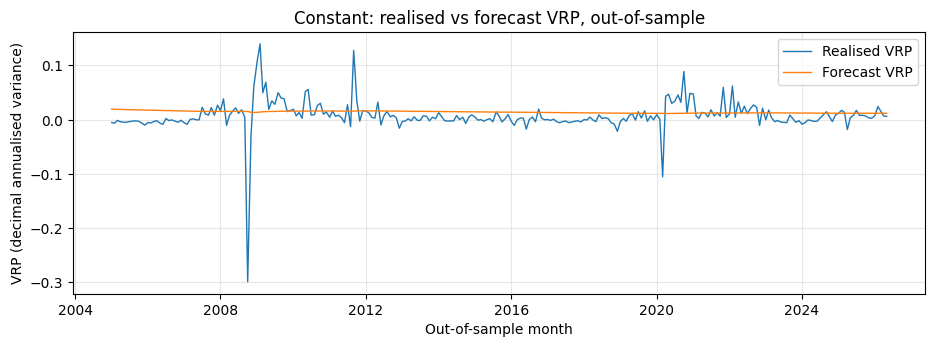

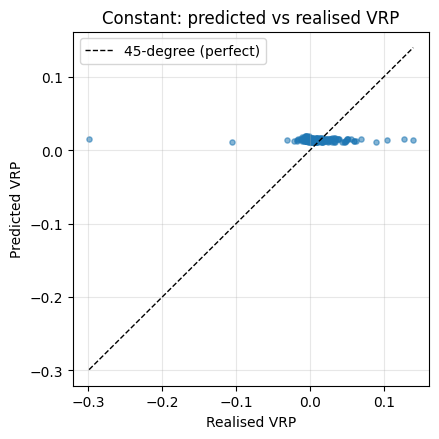

Constant: 5 largest absolute-error months (with regime):


,y_true,y_pred,abs_error,regime
2008-10-01,-0.299033,0.015219,0.314253,stressed
2009-02-02,0.139879,0.013992,0.125886,stressed
2020-03-02,-0.105428,0.011687,0.117114,stressed
2011-09-01,0.127723,0.015678,0.112045,stressed
2009-01-02,0.104755,0.013496,0.091258,stressed



Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):


,model,mean_signed_error,mae,rmse,r2,n_under_predicted,n_over_predicted,worst_regime,worst_regime_mae
0,constant,0.006414,0.016982,0.02994,-0.06214,63,190,stressed,0.037306


In [21]:
_ = run_prediction_diagnostic(wf_constant, "constant", diagnostics_rows)

### Walk-forward HAR-style OLS model (predictions only)

Model 2 in the locked forecast sequence: `HAROLSModel` regresses VRP(t+1) on the VRP horizon columns (`VRP_HORIZON_COLS`): VRP(t), VRP(t-2), and VRP(t-5), sitting 1, 3, and 6 months from the target, refit at every walk-forward step with Newey-West HAC standard errors. The model intentionally trains on a strict subset of the locked feature set, the three horizon columns only, with vix_level, cboe_skew, realised_skew_21d, and regime excluded by design; `fit()` still calls `assert_feature_set_complete` against the full `dataset` passed at construction, not against the training subset, so the exclusion is declared rather than implicit.

This cell reuses `initial_train_end` from the constant baseline run so the two models share an identical OOS window, which the later comparison depends on. The sanity output confirms `n_oos` and the OOS index match `wf_constant` exactly, then prints the verification block documenting which locked features HAR excludes.

In [22]:
from src.models.har_ols import HAROLSModel
from src.validation import VRP_HORIZON_COLS, print_verification_block

# The three VRP horizon columns from the single locked source, never a literal list.
har_feature_cols = list(VRP_HORIZON_COLS)

har_model_factory = make_model_factory_from_class(HAROLSModel, monthly_vrp=dataset)

wf_har = walk_forward(
    dataset,
    feature_cols=har_feature_cols,
    model_factory=har_model_factory,
    initial_train_end=initial_train_end,
    target_col="y",
)

print(f"har_feature_cols:  {har_feature_cols}")
print(f"wf_har.shape:      {wf_har.shape}")
print(f"n_oos:             {len(wf_har)}")
print(f"OOS start:         {wf_har.index[0].date()}")
print(f"OOS end:           {wf_har.index[-1].date()}")
print()
print("head(5):")
print(wf_har.head(5))
print()
print("tail(5):")
print(wf_har.tail(5))
print()

assert len(wf_har) == len(wf_constant), (
    f"HAR n_oos ({len(wf_har)}) does not match constant n_oos ({len(wf_constant)})"
)
assert wf_har.index.equals(wf_constant.index), "HAR OOS index does not match constant OOS index"
print(f"n_oos matches constant baseline ({len(wf_constant)}): True")
print("wf_har.index.equals(wf_constant.index): True")
print()

print_verification_block(
    dataset, har_feature_cols, config_values={"HAR_LAGS_MONTHS": config.HAR_LAGS_MONTHS}
)

har_feature_cols:  ['vrp_h1m', 'vrp_h3m', 'vrp_h6m']
wf_har.shape:      (253, 2)
n_oos:             253
OOS start:         2005-01-03
OOS end:           2026-05-01

head(5):
              y_true    y_pred
2005-01-03 -0.005219  0.008048
2005-02-01 -0.006528  0.003808
2005-03-01 -0.001317  0.002776
2005-04-01 -0.003760  0.005234
2005-05-02 -0.004735  0.002971

tail(5):
              y_true    y_pred
2026-01-02  0.007416  0.008964
2026-02-02  0.024167  0.009841
2026-03-02  0.015792  0.015383
2026-04-01  0.006837  0.012681
2026-05-01  0.006084  0.009911

n_oos matches constant baseline (253): True
wf_har.index.equals(wf_constant.index): True

--- VERIFICATION BLOCK ---
Locked feature set (from context.md): ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Features used in this task: ['vrp_h1m', 'vrp_h3m', 'vrp_h6m']
Locked features present in df:
  vix_level: OK
  cboe_skew: OK
  vrp_h1m: OK
  vrp_h3m: OK
  vrp_h6m: OK
  realised_skew_21d: OK
  regi

### Score the HAR-style OLS model (QLIKE, MSE, DA)

`wf_har` is scored through `src.results.score_walk_forward`, the same shared scorer that produced the constant-baseline floor under the corrected alignment (QLIKE 1.462384, n=223; MSE 0.00089641; DA 0.6245, locked to raw_snapshot_2026-06-17). No parallel scoring path is written here; both models' QLIKE numbers therefore share the identical variance-space convention and forward realised target.

The cell also checks HAR's own guard-trip set (`implied_variance = vix_next^2/VIX_VARIANCE_SCALE - y_pred <= 0`) against the constant's 29 calm months. HAR conditions its forecast on recent VRP rather than the unconditional historical mean, so it is expected to trip the guard far less often; if it trips a similar count instead, that points to the guard biting any model during extreme calm, not a property specific to the naive constant baseline.

In [23]:
import numpy as np
import pandas as pd
from src.results import score_walk_forward

vix_next_har = vix_monthly.shift(-1).reindex(wf_har.index)
har_result = score_walk_forward(wf_har, vix_next_har, spy_returns)

print(f"HAR QLIKE: {har_result['qlike']:.6f}  (n={har_result['qlike_n']})")
print(f"HAR MSE:   {har_result['mse']:.8f}  (n={har_result['mse_n']})")
print(f"HAR DA:    {har_result['directional_accuracy']:.4f}  (n={har_result['da_n']})")
print(f"n_guard_excluded:    {har_result['n_guard_excluded']}")
print(f"n_nan_tail_excluded: {har_result['n_nan_tail_excluded']}")
print()

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame(
            [
                {
                    "model": "har",
                    "QLIKE": round(har_result["qlike"], 6),
                    "QLIKE_n": har_result["qlike_n"],
                    "MSE": round(har_result["mse"], 8),
                    "MSE_n": har_result["mse_n"],
                    "DA": round(har_result["directional_accuracy"], 4),
                    "DA_n": har_result["da_n"],
                }
            ]
        ),
    ],
    ignore_index=True,
)

print("Results table:")
display(results_table)
print()

# HAR's own guard-trip set vs the constant's, both read off the
# shared scorer's implied-variance output (no inline reimplementation of the guard).
_constant_guard_dates = wf_constant.index[constant_result["implied_variance"] <= 0]
_har_guard_dates = wf_har.index[har_result["implied_variance"] <= 0]

_const_set = set(_constant_guard_dates)
_har_set = set(_har_guard_dates)
_overlap = _har_set & _const_set
_har_only = _har_set - _const_set

print(f"Constant guard-trip count: {len(_constant_guard_dates)}")
print(f"HAR guard-trip count:      {len(_har_guard_dates)}")
print()

# HAR guard-trip dates as a DataFrame, sourced from the arrays computed above.
if len(_har_guard_dates) == 0:
    print("HAR guard-trip dates: none")
else:
    har_guard_table = pd.DataFrame(
        {"in_constant_guard_set": [d in _const_set for d in _har_guard_dates]},
        index=pd.DatetimeIndex(_har_guard_dates, name="date"),
    )
    display(har_guard_table)
print()

_har_share = len(_har_set) / len(_const_set) if len(_const_set) else 0.0
print(
    f"HAR trips the guard on {len(_har_set)} month(s) vs the constant's {len(_const_set)} "
    f"({_har_share:.0%}); {len(_overlap)} overlap, {len(_har_only)} HAR-only."
)
if len(_har_set) >= 0.5 * len(_const_set):
    print(
        "FLAG: HAR trips a similar count to the constant; investigate whether the "
        "guard bites any model in extreme calm rather than the naive constant alone."
    )

HAR QLIKE: 0.435924  (n=251)
HAR MSE:   0.00100482  (n=253)
HAR DA:    0.6285  (n=253)
n_guard_excluded:    1
n_nan_tail_excluded: 1

Results table:


,model,QLIKE,QLIKE_n,MSE,MSE_n,DA,DA_n
0,constant,1.462384,223,0.000896,253,0.6245,253
1,har,0.435924,251,0.001005,253,0.6285,253



Constant guard-trip count: 29
HAR guard-trip count:      1



,in_constant_guard_set
date,
2021-12-01,False



HAR trips the guard on 1 month(s) vs the constant's 29 (3%); 0 overlap, 1 HAR-only.


### HAR diagnostics

Per-model diagnostic block for the HAR model, run immediately after its score cell. The cumulative diagnostics table now carries two rows (constant, HAR), so the constant and HAR error profiles can be read side by side.

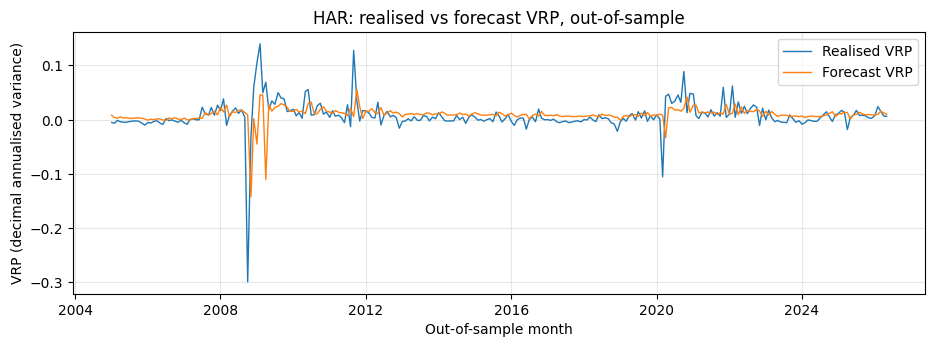

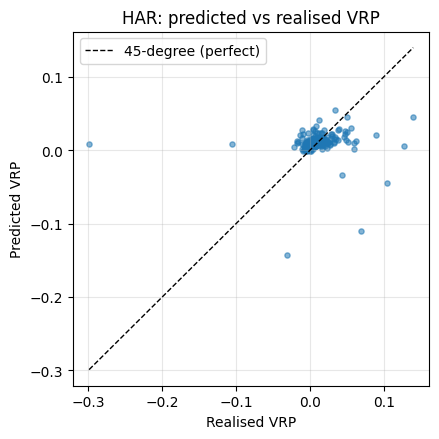

HAR: 5 largest absolute-error months (with regime):


,y_true,y_pred,abs_error,regime
2008-10-01,-0.299033,0.008774,0.307808,stressed
2009-04-01,0.068966,-0.110023,0.178989,stressed
2009-01-02,0.104755,-0.045105,0.149860,stressed
2011-09-01,0.127723,0.005548,0.122175,stressed
2020-03-02,-0.105428,0.008161,0.113589,stressed



Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):


,model,mean_signed_error,mae,rmse,r2,n_under_predicted,n_over_predicted,worst_regime,worst_regime_mae
0,constant,0.006414,0.016982,0.029940,-0.062140,63,190,stressed,0.037306
1,har,0.001941,0.014755,0.031699,-0.190594,74,179,stressed,0.044353


In [24]:
_ = run_prediction_diagnostic(wf_har, "har", diagnostics_rows)

### Compare HAR to the constant baseline (paired subset; bootstrap CW-on-QLIKE primary)

`("constant", "har")` is nested: the constant model is HAR with the three lag coefficients constrained to zero, so the comparison routes to **Clark-West**, not Diebold-Mariano (standard DM has a degenerate asymptotic distribution under nesting and under-rejects). Three conventions govern this comparison and every later nested comparison in the sequence (Extended OLS vs HAR, and so on; DM-on-QLIKE for non-nested pairs):

1. **Paired subset.** The comparison and both significance tests run only on the common-valid intersection, the months where both models produce a valid (strictly positive) implied variance. Each model's full-sample valid QLIKE (constant n=223, HAR n=250) is a descriptive column only, never the comparison number.

2. **Clark-West on QLIKE differentials.** The nested test operates on per-observation QLIKE losses, not MSPE squared errors, so it tests the same quantity as the reported primary loss (variance-space QLIKE, Patton 2011). The per-obs adjusted differential is `f_t = qlike_per_obs(realised, var_smaller) - qlike_per_obs(realised, var_larger) + qlike_per_obs(var_smaller, var_larger)`, which (logs cancel) equals `(l_t - s_t)(r_t - s_t) / (s_t l_t)`, the standard MSPE Clark-West term `2(l_t - s_t)(r_t - s_t)` reweighted by `1 / (2 s_t l_t)`. The adjustment `qlike_per_obs(var_smaller, var_larger)` is the correct second-order bias correction for QLIKE, derived from the loss curvature `1/m*^2` at the H0-true variance, and reduces to the squared-prediction-gap `(pred_s - pred_l)^2` under squared-error loss.

3. **Bootstrap p-value under H0.** The bias-correction centering of `f_t` carries over to QLIKE, but the N(0,1) reference distribution does not (it is squared-error-specific). The nested-pair p-value is therefore obtained by a **circular block bootstrap under the null** (`src.forecast_comparison.clark_west_bootstrap`): `f_t` is re-centered to mean zero to enforce H0, resampled in circular blocks of length `floor(n^(1/3))` (the Hall, Horowitz and Jing 1995 growth rate; circular blocks per Politis and Romano 1992 keep the null mean at zero), and the one-sided p-value is the share of bootstrap means at or beyond the observed mean. Replications and seed come from config. The point statistic and its centering are unchanged; only the p-value source moves from the normal table to the bootstrap. CW-on-MSPE is retained as a secondary cross-check only.

Per-observation QLIKE uses the single shared variance-space conversion and forward realised target owned by `score_walk_forward` (no second QLIKE path). The cell reports the reconciled HAR valid n, the paired n, both models' paired-subset QLIKE, the bootstrap CW-on-QLIKE result (statistic, bootstrap p-value, block length, replications, seed), the CW-on-MSPE cross-check, and the QLIKE-vs-MSE divergence finding.

The corrected Clark-West result for this pair (curvature-weighted adjustment, HAC-studentised statistic, model-based null-imposed bootstrap; `src.corrected_cw`) is read from the persisted `outputs/corrected_cw_results.npz` and shown alongside the pipeline bootstrap p-value it corrects; nothing is recomputed in the cell.

The QLIKE and MSE verdicts diverge, and the divergence is reported as a finding rather than reconciled away. QLIKE is asymmetric and penalises under-forecasting of variance more heavily than over-forecasting, while MSE is symmetric in VRP units. HAR conditions on recent VRP and avoids the large under-forecasts the constant makes when variance rises, which lowers QLIKE sharply, while the small symmetric errors it adds elsewhere raise MSE. The primary QLIKE criterion therefore favours HAR and the secondary MSE does not, consistent with asymmetric loss being the economically relevant criterion for variance forecasts.

In [25]:
import numpy as np
import pandas as pd
from src import config
from src.results import score_walk_forward
from src.metrics import qlike, qlike_per_obs
from src.forecast_comparison import (
    clark_west, clark_west_from_losses, clark_west_bootstrap, is_nested,
)

assert is_nested("constant", "har"), "('constant', 'har') must be in NESTED_MODEL_PAIRS"

# Score BOTH models through the single shared scorer. score_walk_forward owns the
# only variance-space QLIKE conversion and forward realised target; reusing it for
# both models means the paired comparison cannot drift onto a second QLIKE path.
# It exposes valid_mask (= guard_mask & nan_tail_mask), implied_variance, and
# realised_variance_next for pairing.
vix_next_constant = vix_monthly.shift(-1).reindex(wf_constant.index)
vix_next_har = vix_monthly.shift(-1).reindex(wf_har.index)
score_constant = score_walk_forward(wf_constant, vix_next_constant, spy_returns)
score_har = score_walk_forward(wf_har, vix_next_har, spy_returns)

assert wf_constant.index.equals(wf_har.index), "OOS windows are not identical"
# valid masks are positionally aligned because the two OOS indices are identical.

# Valid-n reconciliation from the scorer's own bookkeeping.
n_har_valid = score_har["qlike_n"]
print("=== Valid-n reconciliation ===")
print(f"  HAR: {score_har['n_obs']} OOS months - {score_har['n_guard_excluded']} guard "
      f"- {score_har['n_nan_tail_excluded']} nan-tail = {n_har_valid}.")
print(f"  Constant valid n    = {score_constant['qlike_n']}  (guard {score_constant['n_guard_excluded']}, "
      f"nan-tail {score_constant['n_nan_tail_excluded']}).")
print()

# Paired subset: months where BOTH models give a valid implied variance.
mask_constant = score_constant["valid_mask"]
mask_har = score_har["valid_mask"]
paired_mask = mask_constant & mask_har
n_paired = int(paired_mask.sum())

# realised target is the same forward estimator for both models; assert it.
realised_paired = score_constant["realised_variance_next"][paired_mask]
np.testing.assert_allclose(
    realised_paired, score_har["realised_variance_next"][paired_mask]
)
implied_constant_paired = score_constant["implied_variance"][paired_mask]
implied_har_paired = score_har["implied_variance"][paired_mask]

# Paired-subset QLIKE for BOTH models (the comparison number).
qlike_constant_paired = qlike(realised_paired, implied_constant_paired)
qlike_har_paired = qlike(realised_paired, implied_har_paired)

print("=== Paired-subset QLIKE (the comparison) ===")
print(f"  Paired-subset n:  {n_paired}  (months valid for BOTH models = "
      f"constant {score_constant['qlike_n']} cap har {n_har_valid})")
print(f"  QLIKE constant:   {qlike_constant_paired:.6f}")
print(f"  QLIKE har:        {qlike_har_paired:.6f}")
print(f"  HAR lower QLIKE:  {qlike_har_paired < qlike_constant_paired}")
print()

# PRIMARY: Clark-West on QLIKE differentials with a block-bootstrap p-value.
# Per-obs QLIKE comes from qlike_per_obs (the same path qlike() aggregates) on the
# shared variance-space conversion. The QLIKE CW adjustment is
# qlike_per_obs(var_smaller, var_larger): the larger model's forecast scored
# against the smaller (nested, correct-under-H0) model's forecast as proxy-truth,
# the second-order bias correction that reduces to (pred_s - pred_l)**2 under
# squared error. The N(0,1) reference is not valid for QLIKE, so the p-value comes
# from clark_west_bootstrap (circular block bootstrap, H0 enforced by re-centering
# f_t to mean zero). The studentised point statistic is unchanged.
loss_constant_q = qlike_per_obs(realised_paired, implied_constant_paired)  # smaller
loss_har_q = qlike_per_obs(realised_paired, implied_har_paired)            # larger
adjustment_q = qlike_per_obs(implied_constant_paired, implied_har_paired)

cw_qlike_norm = clark_west_from_losses(loss_constant_q, loss_har_q, adjustment_q, loss="qlike")
cw_qlike = clark_west_bootstrap(loss_constant_q, loss_har_q, adjustment_q, loss="qlike")
cw_result = cw_qlike  # primary adjudicating result
# The re-centering property (bootstrap null distribution centred at zero) is
# pinned by tests/test_forecast_comparison.py, not re-derived inline here.

print("=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===")
print(f"  loss:                 {cw_qlike.loss}")
print(f"  Observed CW statistic:{cw_qlike.statistic:.4f}   (studentised; point statistic, unchanged)")
print(f"  Observed mean f_bar:  {cw_qlike.observed_mean:.6f}   (quantity the bootstrap tests)")
print(f"  Bootstrap p-value:    {cw_qlike.p_value:.6f}   (one-sided, circular block, H0)")
print(f"  Block length:         {cw_qlike.block_length}  = floor({n_paired}^(1/3))  "
      f"(Hall-Horowitz-Jing rate; guards residual dependence)")
print(f"  Replications / seed:  {cw_qlike.n_boot} / {cw_qlike.seed}  (from config)")
print(f"  N (paired):           {cw_qlike.n}")
print(f"  N(0,1) p (superseded):{cw_qlike_norm.p_value:.6f}  (not valid under QLIKE; shown for reference only)")
print(f"  larger_model_wins:    {cw_qlike.larger_model_wins}  (alpha={cw_qlike.alpha})")
if cw_qlike.larger_model_wins:
    print(f"  -> HAR significantly beats the constant baseline on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} < {cw_qlike.alpha}).")
else:
    print(f"  -> HAR does NOT significantly beat the constant on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} >= {cw_qlike.alpha}).")
print()

# SECONDARY (cross-check): Clark-West on MSPE squared errors. Retained as a
# cross-check only; CW-on-MSPE tests a different quantity (symmetric squared error
# in VRP units) than the reported primary and does not adjudicate.
yt_paired = wf_constant["y_true"].to_numpy(float)[paired_mask]
pc_paired = wf_constant["y_pred"].to_numpy(float)[paired_mask]
ph_paired = wf_har["y_pred"].to_numpy(float)[paired_mask]
cw_mspe_paired = clark_west(yt_paired, pc_paired, ph_paired)
cw_mspe_full = clark_west(
    wf_constant["y_true"].to_numpy(float),
    wf_constant["y_pred"].to_numpy(float),
    wf_har["y_pred"].to_numpy(float),
)

print("=== SECONDARY (cross-check): Clark-West on MSPE squared errors ===")
print(f"  Paired subset (n={cw_mspe_paired.n}):  stat={cw_mspe_paired.statistic:.4f}  "
      f"p={cw_mspe_paired.p_value:.6f}  wins={cw_mspe_paired.larger_model_wins}")
print(f"  Full sample   (n={cw_mspe_full.n}):  stat={cw_mspe_full.statistic:.4f}  "
      f"p={cw_mspe_full.p_value:.6f}  wins={cw_mspe_full.larger_model_wins}")
print()

# Augmented results table: full-sample descriptive + paired-subset QLIKE.
comparison_table = pd.DataFrame([
    {"model": "constant",
     "QLIKE_full": round(score_constant["qlike"], 6), "QLIKE_full_n": score_constant["qlike_n"],
     "QLIKE_paired": round(qlike_constant_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_constant["mse"], 8), "MSE_full_n": score_constant["mse_n"]},
    {"model": "har",
     "QLIKE_full": round(score_har["qlike"], 6), "QLIKE_full_n": n_har_valid,
     "QLIKE_paired": round(qlike_har_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_har["mse"], 8), "MSE_full_n": score_har["mse_n"]},
])
print("Results table  (QLIKE_full / MSE_full = descriptive per-model; "
      "QLIKE_paired = comparison subset):")
display(comparison_table)
print()

# Finding: QLIKE-vs-MSE divergence. Numbers in a DataFrame, interpretation in the
# markdown cell for this section. Per-model paired QLIKE and full MSE plus the
# adjudicating bootstrap CW-on-QLIKE and the secondary CW-on-MSPE p-values, all
# sourced from variables.
divergence_table = pd.DataFrame(
    {
        "constant": [qlike_constant_paired, score_constant["mse"]],
        "har": [qlike_har_paired, score_har["mse"]],
        "test": [cw_qlike.test_type, cw_mspe_full.test_type],
        "p_value": [cw_qlike.p_value, cw_mspe_full.p_value],
        "significant_at_alpha": [
            cw_qlike.p_value < config.COMPARISON_ALPHA,
            cw_mspe_full.p_value < config.COMPARISON_ALPHA,
        ],
    },
    index=pd.Index(["QLIKE (paired)", "MSE (full)"], name="loss"),
)
display(divergence_table)
print(
    f"HAR lower paired QLIKE ({qlike_har_paired:.4f} vs {qlike_constant_paired:.4f}), "
    f"CW-on-QLIKE p={cw_qlike.p_value:.4f}; HAR higher full MSE "
    f"({score_har['mse']:.8f} vs {score_constant['mse']:.8f}), CW-on-MSPE p={cw_mspe_full.p_value:.4f}."
)
print()

# Assertions.
assert cw_qlike.test_type == "clark_west_bootstrap" and cw_qlike.loss == "qlike"
assert cw_qlike.statistic == cw_qlike_norm.statistic, "point statistic must be unchanged"
assert cw_qlike.n == n_paired == cw_mspe_paired.n
assert n_paired <= min(score_constant["qlike_n"], n_har_valid)
assert qlike_har_paired < qlike_constant_paired, "expected HAR lower paired QLIKE"
assert cw_qlike.larger_model_wins, "expected HAR to beat constant on bootstrap CW-on-QLIKE"
print("Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested pair; CW-on-MSPE "
      "retained as secondary cross-check; paired n stated.")

# Corrected Clark-West readout for this pair (src.corrected_cw): curvature-weighted
# adjustment, HAC-studentised statistic, model-based null-imposed bootstrap. Read
# from the persisted artifact written by `python -m src.corrected_cw pvalues`.
_cw_path = config.PROJECT_ROOT / "outputs" / "corrected_cw_results.npz"
with np.load(_cw_path, allow_pickle=False) as _cwz:
    corrected_cw_table = pd.DataFrame([{
        "pair": "constant vs har",
        "corrected_statistic": float(_cwz["constant__har__s_obs"]),
        "corrected_p": float(_cwz["constant__har__p_corrected"]),
        "pipeline_bootstrap_p": cw_qlike.p_value,
        "n_draws_used": int(_cwz["constant__har__n_draws_used"]),
        "n_failed": int(_cwz["constant__har__n_failed"]),
    }])
print()
print("Corrected Clark-West (persisted artifact, outputs/corrected_cw_results.npz):")
display(corrected_cw_table)

=== Valid-n reconciliation ===
  HAR: 253 OOS months - 1 guard - 1 nan-tail = 251.
  Constant valid n    = 223  (guard 29, nan-tail 1).

=== Paired-subset QLIKE (the comparison) ===
  Paired-subset n:  222  (months valid for BOTH models = constant 223 cap har 251)
  QLIKE constant:   1.466938
  QLIKE har:        0.443401
  HAR lower QLIKE:  True

=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===
  loss:                 qlike
  Observed CW statistic:3.4658   (studentised; point statistic, unchanged)
  Observed mean f_bar:  1.275904   (quantity the bootstrap tests)
  Bootstrap p-value:    0.004100   (one-sided, circular block, H0)
  Block length:         6  = floor(222^(1/3))  (Hall-Horowitz-Jing rate; guards residual dependence)
  Replications / seed:  9999 / 20260617  (from config)
  N (paired):           222
  N(0,1) p (superseded):0.000264  (not valid under QLIKE; shown for reference only)
  larger_model_wins:    True  (alpha=0.05)
  -> HAR significantly b

,model,QLIKE_full,QLIKE_full_n,QLIKE_paired,QLIKE_paired_n,MSE_full,MSE_full_n
0,constant,1.462384,223,1.466938,222,0.000896,253
1,har,0.435924,251,0.443401,222,0.001005,253


,constant,har,test,p_value,significant_at_alpha
loss,,,,,
QLIKE (paired),1.466938,0.443401,clark_west_bootstrap,0.004100,True
MSE (full),0.000896,0.001005,clark_west,0.065565,False


HAR lower paired QLIKE (0.4434 vs 1.4669), CW-on-QLIKE p=0.0041; HAR higher full MSE (0.00100482 vs 0.00089641), CW-on-MSPE p=0.0656.

Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested pair; CW-on-MSPE retained as secondary cross-check; paired n stated.

Corrected Clark-West (persisted artifact, outputs/corrected_cw_results.npz):


,pair,corrected_statistic,corrected_p,pipeline_bootstrap_p,n_draws_used,n_failed
0,constant vs har,2.0363,0.005701,0.0041,9999,0


### Walk-forward extended OLS model (predictions only)

Model 3 in the locked sequence. `ExtendedOLSModel` regresses VRP(t+1) on the six numeric locked features (vix_level, cboe_skew, the three VRP horizon columns, realised_skew_21d), refit at every walk-forward step with Newey-West HAC standard errors. The locked feature `regime` is categorical and is intentionally excluded as a numeric regressor; `fit()` still calls `assert_feature_set_complete` against the full `dataset`, so the exclusion is declared, not implicit. The six features span about three orders of magnitude (vix_level ~10-80, cboe_skew ~100-170, vrp lags ~0.001-0.05, realised_skew_21d ~-3 to +2), so the model z-scores them before fitting. The scaler is fit on each step's training window only, inside `fit()`, and applied to that step's test point, so it adds no look-ahead; OLS fitted values are invariant to the rescaling, which only changes the coefficient scale.

This cell reuses `initial_train_end` so the OOS window matches the constant baseline and HAR exactly, which the later comparison depends on. The sanity output confirms `n_oos` and the OOS index match `wf_har`, then prints the verification block documenting the regime exclusion.

In [26]:
from src.models.extended_ols import ExtendedOLSModel
from src.validation import print_verification_block

from src.validation import LOCKED_FEATURE_SET

# Six numeric locked features, in LOCKED_FEATURE_SET order minus regime, derived
# from the single locked source. regime is categorical and is intentionally
# excluded as a numeric regressor for this OLS.
extended_feature_cols = [c for c in LOCKED_FEATURE_SET if c != "regime"]

extended_model_factory = make_model_factory_from_class(ExtendedOLSModel, monthly_vrp=dataset)

wf_extended = walk_forward(
    dataset,
    feature_cols=extended_feature_cols,
    model_factory=extended_model_factory,
    initial_train_end=initial_train_end,
    target_col="y",
)

print(f"extended_feature_cols: {extended_feature_cols}")
print(f"wf_extended.shape:     {wf_extended.shape}")
print(f"n_oos:                 {len(wf_extended)}")
print(f"OOS start:             {wf_extended.index[0].date()}")
print(f"OOS end:               {wf_extended.index[-1].date()}")
print()
print("head(5):")
display(wf_extended.head(5))
print()
print("tail(5):")
display(wf_extended.tail(5))
print()

assert len(wf_extended) == len(wf_har) == len(wf_constant), (
    f"Extended n_oos ({len(wf_extended)}) does not match HAR/constant "
    f"({len(wf_har)}/{len(wf_constant)})"
)
assert wf_extended.index.equals(wf_har.index), "Extended OOS index does not match HAR"
print(f"n_oos matches HAR and constant ({len(wf_constant)}): True")
print("wf_extended.index.equals(wf_har.index): True")
print()

print_verification_block(
    dataset, extended_feature_cols,
    config_values={"HAR_LAGS_MONTHS": config.HAR_LAGS_MONTHS},
)

extended_feature_cols: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d']
wf_extended.shape:     (253, 2)
n_oos:                 253
OOS start:             2005-01-03
OOS end:               2026-05-01

head(5):


,y_true,y_pred
2005-01-03,-0.005219,0.010077
2005-02-01,-0.006528,0.006279
2005-03-01,-0.001317,0.005053
2005-04-01,-0.003760,0.006343
2005-05-02,-0.004735,0.008181



tail(5):


,y_true,y_pred
2026-01-02,0.007416,0.003679
2026-02-02,0.024167,0.002823
2026-03-02,0.015792,0.017904
2026-04-01,0.006837,0.018626
2026-05-01,0.006084,0.010717



n_oos matches HAR and constant (253): True
wf_extended.index.equals(wf_har.index): True

--- VERIFICATION BLOCK ---
Locked feature set (from context.md): ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Features used in this task: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d']
Locked features present in df:
  vix_level: OK
  cboe_skew: OK
  vrp_h1m: OK
  vrp_h3m: OK
  vrp_h6m: OK
  realised_skew_21d: OK
  regime: OK
Locked features absent from feature list (intentional exclusions, e.g. HAR): ['regime']
Config values referenced:
  HAR_LAGS_MONTHS: (1, 3, 6)
--- END VERIFICATION BLOCK ---


### Score the extended OLS model (QLIKE, MSE, DA)

`wf_extended` is scored through `src.results.score_walk_forward`, the same shared scorer used for the constant baseline and HAR, so all three models' QLIKE numbers share one variance-space convention and one forward realised target with no parallel scoring path. QLIKE is reported on the valid subset; MSE and DA on all OOS months. The cell appends the `extended_ols` row to `results_table` and reports the guard-trip count, the months where `vix_next^2 / VIX_VARIANCE_SCALE - y_pred <= 0` makes the implied variance non-positive, which are excluded from QLIKE only, never from the dataset.

In [27]:
import pandas as pd
from src.results import score_walk_forward

vix_next_extended = vix_monthly.shift(-1).reindex(wf_extended.index)
extended_result = score_walk_forward(wf_extended, vix_next_extended, spy_returns)

print(f"Extended OLS QLIKE: {extended_result['qlike']:.6f}  (n={extended_result['qlike_n']})")
print(f"Extended OLS MSE:   {extended_result['mse']:.8f}  (n={extended_result['mse_n']})")
print(f"Extended OLS DA:    {extended_result['directional_accuracy']:.4f}  (n={extended_result['da_n']})")
print(f"n_guard_excluded:    {extended_result['n_guard_excluded']}")
print(f"n_nan_tail_excluded: {extended_result['n_nan_tail_excluded']}")
print()

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([{
            "model": "extended_ols",
            "QLIKE": round(extended_result["qlike"], 6),
            "QLIKE_n": extended_result["qlike_n"],
            "MSE": round(extended_result["mse"], 8),
            "MSE_n": extended_result["mse_n"],
            "DA": round(extended_result["directional_accuracy"], 4),
            "DA_n": extended_result["da_n"],
        }]),
    ],
    ignore_index=True,
)

print("Results table:")
display(results_table)

Extended OLS QLIKE: 2.375025  (n=249)
Extended OLS MSE:   0.00130732  (n=253)
Extended OLS DA:    0.6364  (n=253)
n_guard_excluded:    3
n_nan_tail_excluded: 1

Results table:


,model,QLIKE,QLIKE_n,MSE,MSE_n,DA,DA_n
0,constant,1.462384,223,0.000896,253,0.6245,253
1,har,0.435924,251,0.001005,253,0.6285,253
2,extended_ols,2.375025,249,0.001307,253,0.6364,253


### Extended OLS diagnostics

Per-model diagnostic block for extended OLS, the current best model on QLIKE, run immediately after its score cell. The cumulative diagnostics table now carries three rows. The largest-misses table shows whether the biggest VRP misses concentrate in stressed months.

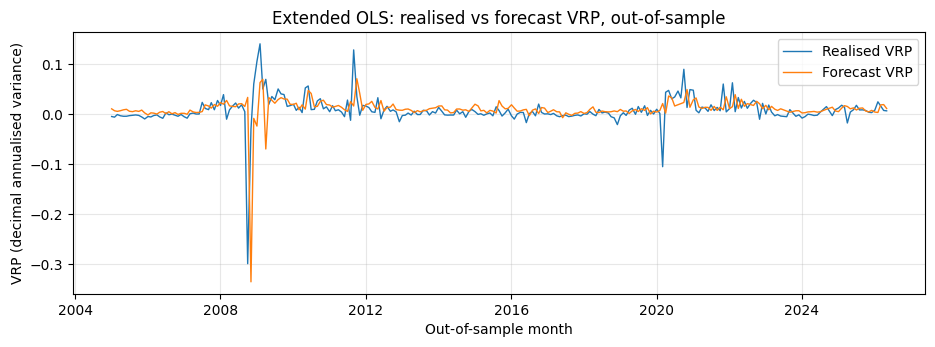

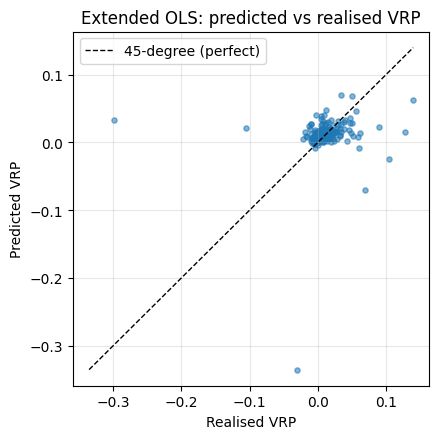

Extended OLS: 5 largest absolute-error months (with regime):


,y_true,y_pred,abs_error,regime
2008-10-01,-0.299033,0.032934,0.331967,stressed
2008-11-03,-0.030445,-0.335236,0.304792,stressed
2009-04-01,0.068966,-0.070062,0.139028,stressed
2009-01-02,0.104755,-0.024318,0.129073,stressed
2020-03-02,-0.105428,0.020666,0.126094,stressed



Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):


,model,mean_signed_error,mae,rmse,r2,n_under_predicted,n_over_predicted,worst_regime,worst_regime_mae
0,constant,0.006414,0.016982,0.029940,-0.062140,63,190,stressed,0.037306
1,har,0.001941,0.014755,0.031699,-0.190594,74,179,stressed,0.044353
2,extended_ols,0.002445,0.015538,0.036157,-0.549021,73,180,stressed,0.048458


In [28]:
_ = run_prediction_diagnostic(wf_extended, "extended_ols", diagnostics_rows)

### Compare extended OLS to HAR (paired subset; bootstrap CW-on-QLIKE primary)

`("har", "extended_ols")` is nested: HAR is extended OLS with the vix_level, cboe_skew, and realised_skew_21d coefficients constrained to zero, so the comparison routes to Clark-West, not Diebold-Mariano (standard DM has a degenerate asymptotic distribution under nesting and under-rejects). The three conventions apply exactly as in the HAR-vs-constant comparison. First, the test runs on the paired valid subset, the months where both models give a strictly positive implied variance; each model's full-sample valid QLIKE is descriptive only. Second, Clark-West operates on per-observation QLIKE differentials (variance-space, Patton 2011), the same quantity as the reported primary loss, with adjustment `qlike_per_obs(var_smaller, var_larger)` (the larger model's forecast scored against the smaller model's forecast as proxy-truth). Third, the p-value comes from the circular block bootstrap under H0 (`clark_west_bootstrap`), because the N(0,1) reference is squared-error-specific and not valid for QLIKE; replications, seed, and block-length rule come from config.

Per-observation QLIKE uses the single shared variance-space conversion and forward realised target owned by `score_walk_forward`. CW-on-MSPE is retained as a secondary cross-check only. The cell reports the paired n, both models' paired-subset QLIKE, the observed CW statistic, the bootstrap p-value, the secondary CW-on-MSPE result, and the verdict on whether extended OLS significantly beats HAR on QLIKE.

In [29]:
import numpy as np
import pandas as pd
from src import config
from src.results import score_walk_forward
from src.metrics import qlike, qlike_per_obs
from src.forecast_comparison import (
    clark_west, clark_west_from_losses, clark_west_bootstrap, is_nested,
)

assert is_nested("har", "extended_ols"), "('har', 'extended_ols') must be in NESTED_MODEL_PAIRS"

# Score BOTH models through the single shared scorer (no second QLIKE path). It
# exposes valid_mask (= guard_mask & nan_tail_mask), implied_variance, and
# realised_variance_next for pairing.
vix_next_har = vix_monthly.shift(-1).reindex(wf_har.index)
vix_next_extended = vix_monthly.shift(-1).reindex(wf_extended.index)
score_har = score_walk_forward(wf_har, vix_next_har, spy_returns)
score_extended = score_walk_forward(wf_extended, vix_next_extended, spy_returns)

assert wf_har.index.equals(wf_extended.index), "OOS windows are not identical"
# valid masks are positionally aligned because the two OOS indices are identical.

# Paired subset: months where BOTH models give a valid implied variance.
mask_har = score_har["valid_mask"]
mask_extended = score_extended["valid_mask"]
paired_mask = mask_har & mask_extended
n_paired = int(paired_mask.sum())

# realised target is the same forward estimator for both models; assert it.
realised_paired = score_har["realised_variance_next"][paired_mask]
np.testing.assert_allclose(
    realised_paired, score_extended["realised_variance_next"][paired_mask]
)
implied_har_paired = score_har["implied_variance"][paired_mask]
implied_extended_paired = score_extended["implied_variance"][paired_mask]

# Paired-subset QLIKE for BOTH models (the comparison number).
qlike_har_paired = qlike(realised_paired, implied_har_paired)
qlike_extended_paired = qlike(realised_paired, implied_extended_paired)

print("=== Paired-subset QLIKE (the comparison) ===")
print(f"  HAR valid n:          {score_har['qlike_n']}  (guard {score_har['n_guard_excluded']}, "
      f"nan-tail {score_har['n_nan_tail_excluded']})")
print(f"  Extended valid n:     {score_extended['qlike_n']}  (guard {score_extended['n_guard_excluded']}, "
      f"nan-tail {score_extended['n_nan_tail_excluded']})")
print(f"  Paired-subset n:      {n_paired}  (months valid for BOTH models)")
print(f"  QLIKE har:            {qlike_har_paired:.6f}")
print(f"  QLIKE extended:       {qlike_extended_paired:.6f}")
print(f"  Extended lower QLIKE: {qlike_extended_paired < qlike_har_paired}")
print()

# PRIMARY: Clark-West on QLIKE differentials with a block-bootstrap p-value.
# smaller = HAR (nested, correct-under-H0), larger = Extended OLS. The adjustment
# qlike_per_obs(var_har, var_extended) is the second-order QLIKE bias correction,
# reducing to (pred_s - pred_l)**2 under squared error. The N(0,1) reference is not
# valid for QLIKE, so the p-value comes from clark_west_bootstrap (circular block
# bootstrap, H0 enforced by re-centering f_t to mean zero); the studentised point
# statistic is unchanged.
loss_har_q = qlike_per_obs(realised_paired, implied_har_paired)            # smaller
loss_extended_q = qlike_per_obs(realised_paired, implied_extended_paired)  # larger
adjustment_q = qlike_per_obs(implied_har_paired, implied_extended_paired)

cw_qlike_norm = clark_west_from_losses(loss_har_q, loss_extended_q, adjustment_q, loss="qlike")
cw_qlike = clark_west_bootstrap(loss_har_q, loss_extended_q, adjustment_q, loss="qlike")

print("=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===")
print(f"  loss:                  {cw_qlike.loss}")
print(f"  Observed CW statistic: {cw_qlike.statistic:.4f}   (studentised point statistic, unchanged)")
print(f"  Observed mean f_bar:   {cw_qlike.observed_mean:.6f}   (quantity the bootstrap tests)")
print(f"  Bootstrap p-value:     {cw_qlike.p_value:.6f}   (one-sided, circular block, H0)")
print(f"  Block length:          {cw_qlike.block_length}  = floor({n_paired}^(1/3))  "
      f"(Hall-Horowitz-Jing rate)")
print(f"  Replications / seed:   {cw_qlike.n_boot} / {cw_qlike.seed}  (from config)")
print(f"  N (paired):            {cw_qlike.n}")
print(f"  N(0,1) p (superseded): {cw_qlike_norm.p_value:.6f}  (not valid under QLIKE; reference only)")
print(f"  larger_model_wins:     {cw_qlike.larger_model_wins}  (alpha={cw_qlike.alpha})")
if cw_qlike.larger_model_wins:
    print(f"  -> Extended OLS significantly beats HAR on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} < {cw_qlike.alpha}).")
else:
    print(f"  -> Extended OLS does NOT significantly beat HAR on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} >= {cw_qlike.alpha}).")
print()

# SECONDARY (cross-check): Clark-West on MSPE squared errors. Tests a different
# quantity (symmetric squared error in VRP units) than the primary; does not adjudicate.
yt_paired = wf_har["y_true"].to_numpy(float)[paired_mask]
ph_paired = wf_har["y_pred"].to_numpy(float)[paired_mask]
pe_paired = wf_extended["y_pred"].to_numpy(float)[paired_mask]
cw_mspe_paired = clark_west(yt_paired, ph_paired, pe_paired)

print("=== SECONDARY (cross-check): Clark-West on MSPE squared errors ===")
print(f"  Paired subset (n={cw_mspe_paired.n}):  stat={cw_mspe_paired.statistic:.4f}  "
      f"p={cw_mspe_paired.p_value:.6f}  wins={cw_mspe_paired.larger_model_wins}")
print()

# Comparison table: per-model paired-subset QLIKE plus full-sample descriptive QLIKE/MSE.
comparison_table_extended = pd.DataFrame([
    {"model": "har",
     "QLIKE_full": round(score_har["qlike"], 6), "QLIKE_full_n": score_har["qlike_n"],
     "QLIKE_paired": round(qlike_har_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_har["mse"], 8)},
    {"model": "extended_ols",
     "QLIKE_full": round(score_extended["qlike"], 6), "QLIKE_full_n": score_extended["qlike_n"],
     "QLIKE_paired": round(qlike_extended_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_extended["mse"], 8)},
])
print("Results table  (QLIKE_full / MSE_full = descriptive per-model; "
      "QLIKE_paired = comparison subset):")
display(comparison_table_extended)
print()

# Assertions. No directional assertion on the verdict: whether Extended OLS beats
# HAR is the result being reported, not a precondition.
assert cw_qlike.test_type == "clark_west_bootstrap" and cw_qlike.loss == "qlike"
assert cw_qlike.statistic == cw_qlike_norm.statistic, "point statistic must be unchanged"
assert cw_qlike.n == n_paired == cw_mspe_paired.n
assert n_paired <= min(score_har["qlike_n"], score_extended["qlike_n"])
print("Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested HAR vs Extended OLS "
      "pair (primary, H0 enforced by re-centering); CW-on-MSPE retained as secondary "
      "cross-check; paired n stated.")

=== Paired-subset QLIKE (the comparison) ===
  HAR valid n:          251  (guard 1, nan-tail 1)
  Extended valid n:     249  (guard 3, nan-tail 1)
  Paired-subset n:      249  (months valid for BOTH models)
  QLIKE har:            0.419371
  QLIKE extended:       2.375025
  Extended lower QLIKE: False

=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===
  loss:                  qlike
  Observed CW statistic: -0.9821   (studentised point statistic, unchanged)
  Observed mean f_bar:   -1.612503   (quantity the bootstrap tests)
  Bootstrap p-value:     0.790000   (one-sided, circular block, H0)
  Block length:          6  = floor(249^(1/3))  (Hall-Horowitz-Jing rate)
  Replications / seed:   9999 / 20260617  (from config)
  N (paired):            249
  N(0,1) p (superseded): 0.836981  (not valid under QLIKE; reference only)
  larger_model_wins:     False  (alpha=0.05)
  -> Extended OLS does NOT significantly beat HAR on QLIKE (bootstrap p=0.790000 >= 0.05).

=== 

,model,QLIKE_full,QLIKE_full_n,QLIKE_paired,QLIKE_paired_n,MSE_full
0,har,0.435924,251,0.419371,249,0.001005
1,extended_ols,2.375025,249,2.375025,249,0.001307



Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested HAR vs Extended OLS pair (primary, H0 enforced by re-centering); CW-on-MSPE retained as secondary cross-check; paired n stated.


### Walk-forward regime-switching OLS model (predictions only)

Model 4 in the locked sequence. `RegimeSwitchingOLSModel` fits a separate standardised OLS per regime (calm, normal, stressed) on the six numeric locked features, with each regime's scaler and coefficients estimated on that regime's training rows only; the regime label is the switch key that selects which fitted set to apply at the test month, not a numeric regressor. This is the locked regime-switching definition (separate coefficient sets), not a regime dummy in one pooled regression. When a regime's expanding-window training subset holds fewer than `min_obs` observations (`REGIME_MIN_TRAIN_MULTIPLIER` times the seven parameters, so 14), that step falls back to the pooled Extended OLS coefficients rather than an unstable near-saturated per-regime fit; `regime_fallback_log` replays the per-step decision so the count is reported, not silent.

This cell reuses `initial_train_end` so the OOS window matches the constant baseline, HAR, and Extended OLS exactly, which the later comparison depends on. The output should confirm `n_oos` is 253 with the OOS index matching `wf_extended`, show which regimes and how many steps used the fallback (the stressed regime in the early years is the expected trigger), then print the verification block showing the full locked feature set is consumed.

In [30]:
from src.models.regime_switching_ols import (
    RegimeSwitchingOLSModel, NUMERIC_FEATURES, regime_fallback_log,
)
from src.validation import print_verification_block

# Six numeric regressors plus the regime switch key. regime is consumed as the
# key selecting which per-regime coefficient set to apply, not as a numeric
# regressor, so the full locked feature set is used by this model.
regime_switching_feature_cols = list(NUMERIC_FEATURES) + ["regime"]

regime_switching_model_factory = make_model_factory_from_class(
    RegimeSwitchingOLSModel, monthly_vrp=dataset,
)

wf_regime_ols = walk_forward(
    dataset,
    feature_cols=regime_switching_feature_cols,
    model_factory=regime_switching_model_factory,
    initial_train_end=initial_train_end,
    target_col="y",
)

print(f"regime_switching_feature_cols: {regime_switching_feature_cols}")
print(f"wf_regime_ols.shape:           {wf_regime_ols.shape}")
print(f"n_oos:                         {len(wf_regime_ols)}")
print(f"OOS start:                     {wf_regime_ols.index[0].date()}")
print(f"OOS end:                       {wf_regime_ols.index[-1].date()}")
print()
print("head(5):")
display(wf_regime_ols.head(5))
print()
print("tail(5):")
display(wf_regime_ols.tail(5))
print()

assert len(wf_regime_ols) == len(wf_extended) == len(wf_constant), (
    f"Regime-switching n_oos ({len(wf_regime_ols)}) does not match "
    f"Extended/constant ({len(wf_extended)}/{len(wf_constant)})"
)
assert wf_regime_ols.index.equals(wf_extended.index), "Regime-switching OOS index does not match Extended OLS"
print(f"n_oos matches Extended OLS and constant ({len(wf_constant)}): True")
print("wf_regime_ols.index.equals(wf_extended.index): True")
print()

# Fallback report: deterministic per-step replay of the regime-switch decision.
# fallback at step t+1 iff the test month's regime has < min_obs training rows.
fallback_log = regime_fallback_log(dataset, initial_train_end)
n_fallback = int(fallback_log["fallback"].sum())
min_obs = int(fallback_log["min_obs"].iloc[0])
print(f"min_obs per regime for a separate fit: {min_obs}  "
      f"(= REGIME_MIN_TRAIN_MULTIPLIER * (len(NUMERIC_FEATURES) + 1))")
print(f"Steps using the pooled fallback: {n_fallback} of {len(fallback_log)}")
print()

fallback_summary = fallback_log.groupby("regime")["fallback"].agg(
    n_oos_steps="size", n_fallback="sum"
)
fallback_summary["n_fallback"] = fallback_summary["n_fallback"].astype(int)
print("Fallback steps by regime (n_oos_steps = OOS months in that regime):")
display(fallback_summary)
print()

print_verification_block(
    dataset, regime_switching_feature_cols,
    config_values={
        "HAR_LAGS_MONTHS": config.HAR_LAGS_MONTHS,
        "REGIME_MIN_TRAIN_MULTIPLIER": config.REGIME_MIN_TRAIN_MULTIPLIER,
    },
)

regime_switching_feature_cols: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
wf_regime_ols.shape:           (253, 2)
n_oos:                         253
OOS start:                     2005-01-03
OOS end:                       2026-05-01

head(5):


,y_true,y_pred
2005-01-03,-0.005219,0.001259
2005-02-01,-0.006528,-0.002355
2005-03-01,-0.001317,-0.004223
2005-04-01,-0.003760,-0.001215
2005-05-02,-0.004735,0.009097



tail(5):


,y_true,y_pred
2026-01-02,0.007416,0.004652
2026-02-02,0.024167,0.007159
2026-03-02,0.015792,0.012640
2026-04-01,0.006837,0.012454
2026-05-01,0.006084,0.014287



n_oos matches Extended OLS and constant (253): True
wf_regime_ols.index.equals(wf_extended.index): True

min_obs per regime for a separate fit: 14  (= REGIME_MIN_TRAIN_MULTIPLIER * (len(NUMERIC_FEATURES) + 1))
Steps using the pooled fallback: 0 of 253

Fallback steps by regime (n_oos_steps = OOS months in that regime):


,n_oos_steps,n_fallback
regime,,
calm,92,0
normal,120,0
stressed,41,0



--- VERIFICATION BLOCK ---
Locked feature set (from context.md): ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Features used in this task: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Locked features present in df:
  vix_level: OK
  cboe_skew: OK
  vrp_h1m: OK
  vrp_h3m: OK
  vrp_h6m: OK
  realised_skew_21d: OK
  regime: OK
Locked features absent from feature list (intentional exclusions, e.g. HAR): []
Config values referenced:
  HAR_LAGS_MONTHS: (1, 3, 6)
  REGIME_MIN_TRAIN_MULTIPLIER: 2
--- END VERIFICATION BLOCK ---


### Score the regime-switching OLS model (QLIKE, MSE, DA)

`wf_regime_ols` is scored through `src.results.score_walk_forward`, the same shared scorer used for every prior model, so its QLIKE shares the one variance-space convention and one forward realised target with no parallel scoring path. QLIKE is reported on the valid subset; MSE and DA on all OOS months. The cell appends the `regime_switching` row to `results_table` and reports the guard-trip and nan-tail counts, the months excluded from QLIKE only, never from the dataset.

In [31]:
import pandas as pd
from src.results import score_walk_forward

vix_next_regime_ols = vix_monthly.shift(-1).reindex(wf_regime_ols.index)
regime_ols_result = score_walk_forward(wf_regime_ols, vix_next_regime_ols, spy_returns)

print(f"Regime-switching OLS QLIKE: {regime_ols_result['qlike']:.6f}  (n={regime_ols_result['qlike_n']})")
print(f"Regime-switching OLS MSE:   {regime_ols_result['mse']:.8f}  (n={regime_ols_result['mse_n']})")
print(f"Regime-switching OLS DA:    {regime_ols_result['directional_accuracy']:.4f}  (n={regime_ols_result['da_n']})")
print(f"n_guard_excluded:    {regime_ols_result['n_guard_excluded']}")
print(f"n_nan_tail_excluded: {regime_ols_result['n_nan_tail_excluded']}")
print()

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([{
            "model": "regime_switching",
            "QLIKE": round(regime_ols_result["qlike"], 6),
            "QLIKE_n": regime_ols_result["qlike_n"],
            "MSE": round(regime_ols_result["mse"], 8),
            "MSE_n": regime_ols_result["mse_n"],
            "DA": round(regime_ols_result["directional_accuracy"], 4),
            "DA_n": regime_ols_result["da_n"],
        }]),
    ],
    ignore_index=True,
)

print("Results table:")
display(results_table)

Regime-switching OLS QLIKE: 0.814857  (n=247)
Regime-switching OLS MSE:   0.00273563  (n=253)
Regime-switching OLS DA:    0.6917  (n=253)
n_guard_excluded:    5
n_nan_tail_excluded: 1

Results table:


,model,QLIKE,QLIKE_n,MSE,MSE_n,DA,DA_n
0,constant,1.462384,223,0.000896,253,0.6245,253
1,har,0.435924,251,0.001005,253,0.6285,253
2,extended_ols,2.375025,249,0.001307,253,0.6364,253
3,regime_switching,0.814857,247,0.002736,253,0.6917,253


### Regime-switching OLS diagnostics

Per-model diagnostic block for regime-switching OLS, run immediately after its score cell per the standing diagnostics rule. The cumulative diagnostics table now carries four rows. The largest-misses table shows whether separate per-regime coefficients move where the biggest VRP misses fall relative to Extended OLS, in particular whether stressed-month errors shrink.

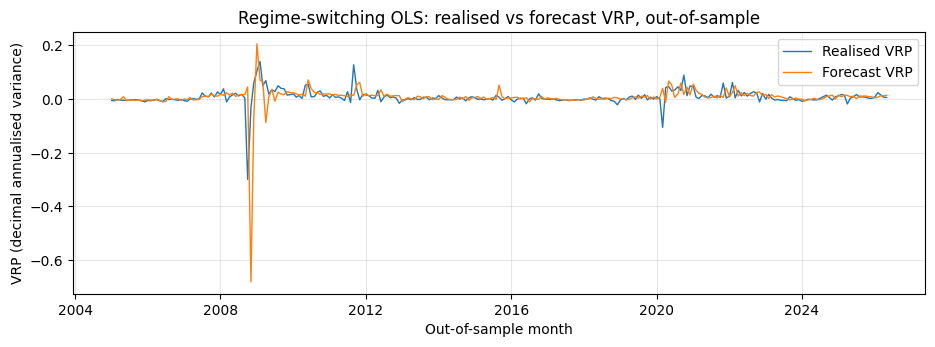

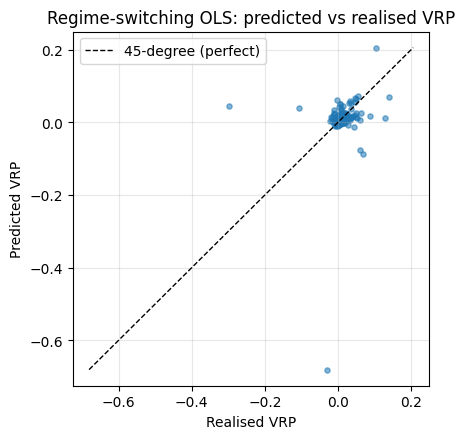

Regime-switching OLS: 5 largest absolute-error months (with regime):


,y_true,y_pred,abs_error,regime
2008-11-03,-0.030445,-0.680690,0.650246,stressed
2008-10-01,-0.299033,0.045449,0.344482,stressed
2009-04-01,0.068966,-0.087615,0.156581,stressed
2020-03-02,-0.105428,0.040530,0.145958,stressed
2008-12-01,0.059816,-0.075792,0.135608,stressed



Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):


,model,mean_signed_error,mae,rmse,r2,n_under_predicted,n_over_predicted,worst_regime,worst_regime_mae
0,constant,0.006414,0.016982,0.029940,-0.062140,63,190,stressed,0.037306
1,har,0.001941,0.014755,0.031699,-0.190594,74,179,stressed,0.044353
2,extended_ols,0.002445,0.015538,0.036157,-0.549021,73,180,stressed,0.048458
3,regime_switching,-0.000236,0.016835,0.052303,-2.241397,101,152,stressed,0.063156


In [32]:
_ = run_prediction_diagnostic(wf_regime_ols, "regime_switching", diagnostics_rows)

### Compare regime-switching OLS to Extended OLS (paired subset; bootstrap CW-on-QLIKE primary)

`("extended_ols", "regime_switching")` is nested: Extended OLS is the equality restriction where all regimes share one coefficient set and one pooled scaler, so regime-switching is the larger model and the comparison routes to Clark-West, not Diebold-Mariano (standard DM has a degenerate asymptotic distribution under nesting and under-rejects). The three conventions from the earlier nested comparisons apply. The test runs on the paired valid subset, the months where both models give a strictly positive implied variance; each model's full-sample valid QLIKE is descriptive only. Clark-West operates on per-observation QLIKE differentials (variance-space, Patton 2011), the same quantity as the reported primary loss, with adjustment `qlike_per_obs(var_extended, var_regime)` (the larger model's forecast scored against the smaller model's forecast as proxy-truth). The p-value comes from the circular block bootstrap under H0 (`clark_west_bootstrap`), because the N(0,1) reference is squared-error-specific and not valid for QLIKE; replications, seed, and block-length rule come from config.

Per-observation QLIKE uses the single shared variance-space conversion and forward realised target owned by `score_walk_forward`. CW-on-MSPE is retained as a secondary cross-check only. The cell reports the paired n, both models' paired-subset QLIKE, the observed CW statistic, the bootstrap p-value, the secondary CW-on-MSPE result, and the verdict on whether regime-switching significantly beats Extended OLS on QLIKE.

In [33]:
import numpy as np
import pandas as pd
from src import config
from src.results import score_walk_forward
from src.metrics import qlike, qlike_per_obs
from src.forecast_comparison import (
    clark_west, clark_west_from_losses, clark_west_bootstrap, is_nested,
)

assert is_nested("extended_ols", "regime_switching"), (
    "('extended_ols', 'regime_switching') must be in NESTED_MODEL_PAIRS"
)

# Score BOTH models through the single shared scorer (no second QLIKE path). It
# exposes valid_mask (= guard_mask & nan_tail_mask), implied_variance, and
# realised_variance_next for pairing.
vix_next_extended = vix_monthly.shift(-1).reindex(wf_extended.index)
vix_next_regime_ols = vix_monthly.shift(-1).reindex(wf_regime_ols.index)
score_extended = score_walk_forward(wf_extended, vix_next_extended, spy_returns)
score_regime_ols = score_walk_forward(wf_regime_ols, vix_next_regime_ols, spy_returns)

assert wf_extended.index.equals(wf_regime_ols.index), "OOS windows are not identical"
# valid masks are positionally aligned because the two OOS indices are identical.

# Paired subset: months where BOTH models give a valid implied variance.
mask_extended = score_extended["valid_mask"]
mask_regime = score_regime_ols["valid_mask"]
paired_mask = mask_extended & mask_regime
n_paired = int(paired_mask.sum())

# realised target is the same forward estimator for both models; assert it.
realised_paired = score_extended["realised_variance_next"][paired_mask]
np.testing.assert_allclose(
    realised_paired, score_regime_ols["realised_variance_next"][paired_mask]
)
implied_extended_paired = score_extended["implied_variance"][paired_mask]
implied_regime_paired = score_regime_ols["implied_variance"][paired_mask]

# Paired-subset QLIKE for BOTH models (the comparison number).
qlike_extended_paired = qlike(realised_paired, implied_extended_paired)
qlike_regime_paired = qlike(realised_paired, implied_regime_paired)

print("=== Paired-subset QLIKE (the comparison) ===")
print(f"  Extended valid n:         {score_extended['qlike_n']}  (guard {score_extended['n_guard_excluded']}, "
      f"nan-tail {score_extended['n_nan_tail_excluded']})")
print(f"  Regime-switching valid n: {score_regime_ols['qlike_n']}  (guard {score_regime_ols['n_guard_excluded']}, "
      f"nan-tail {score_regime_ols['n_nan_tail_excluded']})")
print(f"  Paired-subset n:          {n_paired}  (months valid for BOTH models)")
print(f"  QLIKE extended:           {qlike_extended_paired:.6f}")
print(f"  QLIKE regime-switching:   {qlike_regime_paired:.6f}")
print(f"  Regime-switching lower:   {qlike_regime_paired < qlike_extended_paired}")
print()

# PRIMARY: Clark-West on QLIKE differentials with a block-bootstrap p-value.
# smaller = Extended OLS (the equality-restricted, correct-under-H0 model),
# larger = regime-switching OLS. The adjustment qlike_per_obs(var_extended,
# var_regime) is the second-order QLIKE bias correction, reducing to
# (pred_s - pred_l)**2 under squared error. The N(0,1) reference is not valid for
# QLIKE, so the p-value comes from clark_west_bootstrap (circular block bootstrap,
# H0 enforced by re-centering f_t to mean zero); the studentised point statistic
# is unchanged.
loss_extended_q = qlike_per_obs(realised_paired, implied_extended_paired)  # smaller
loss_regime_q = qlike_per_obs(realised_paired, implied_regime_paired)      # larger
adjustment_q = qlike_per_obs(implied_extended_paired, implied_regime_paired)

cw_qlike_norm = clark_west_from_losses(loss_extended_q, loss_regime_q, adjustment_q, loss="qlike")
cw_qlike = clark_west_bootstrap(loss_extended_q, loss_regime_q, adjustment_q, loss="qlike")

print("=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===")
print(f"  loss:                  {cw_qlike.loss}")
print(f"  Observed CW statistic: {cw_qlike.statistic:.4f}   (studentised point statistic, unchanged)")
print(f"  Observed mean f_bar:   {cw_qlike.observed_mean:.6f}   (quantity the bootstrap tests)")
print(f"  Bootstrap p-value:     {cw_qlike.p_value:.6f}   (one-sided, circular block, H0)")
print(f"  Block length:          {cw_qlike.block_length}  = floor({n_paired}^(1/3))  "
      f"(Hall-Horowitz-Jing rate)")
print(f"  Replications / seed:   {cw_qlike.n_boot} / {cw_qlike.seed}  (from config)")
print(f"  N (paired):            {cw_qlike.n}")
print(f"  N(0,1) p (superseded): {cw_qlike_norm.p_value:.6f}  (not valid under QLIKE; reference only)")
print(f"  larger_model_wins:     {cw_qlike.larger_model_wins}  (alpha={cw_qlike.alpha})")
if cw_qlike.larger_model_wins:
    print(f"  -> Regime-switching OLS significantly beats Extended OLS on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} < {cw_qlike.alpha}).")
else:
    print(f"  -> Regime-switching OLS does NOT significantly beat Extended OLS on QLIKE "
          f"(bootstrap p={cw_qlike.p_value:.6f} >= {cw_qlike.alpha}).")
print()

# SECONDARY (cross-check): Clark-West on MSPE squared errors. Tests a different
# quantity (symmetric squared error in VRP units) than the primary; does not adjudicate.
yt_paired = wf_extended["y_true"].to_numpy(float)[paired_mask]
pe_paired = wf_extended["y_pred"].to_numpy(float)[paired_mask]
pr_paired = wf_regime_ols["y_pred"].to_numpy(float)[paired_mask]
cw_mspe_paired = clark_west(yt_paired, pe_paired, pr_paired)

print("=== SECONDARY (cross-check): Clark-West on MSPE squared errors ===")
print(f"  Paired subset (n={cw_mspe_paired.n}):  stat={cw_mspe_paired.statistic:.4f}  "
      f"p={cw_mspe_paired.p_value:.6f}  wins={cw_mspe_paired.larger_model_wins}")
print()

# Comparison table: per-model paired-subset QLIKE plus full-sample descriptive QLIKE/MSE.
comparison_table_regime = pd.DataFrame([
    {"model": "extended_ols",
     "QLIKE_full": round(score_extended["qlike"], 6), "QLIKE_full_n": score_extended["qlike_n"],
     "QLIKE_paired": round(qlike_extended_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_extended["mse"], 8)},
    {"model": "regime_switching",
     "QLIKE_full": round(score_regime_ols["qlike"], 6), "QLIKE_full_n": score_regime_ols["qlike_n"],
     "QLIKE_paired": round(qlike_regime_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_regime_ols["mse"], 8)},
])
print("Results table  (QLIKE_full / MSE_full = descriptive per-model; "
      "QLIKE_paired = comparison subset):")
display(comparison_table_regime)
print()

# Assertions. No directional assertion on the verdict: whether regime-switching
# beats Extended OLS is the result being reported, not a precondition.
assert cw_qlike.test_type == "clark_west_bootstrap" and cw_qlike.loss == "qlike"
assert cw_qlike.statistic == cw_qlike_norm.statistic, "point statistic must be unchanged"
assert cw_qlike.n == n_paired == cw_mspe_paired.n
assert n_paired <= min(score_extended["qlike_n"], score_regime_ols["qlike_n"])
print("Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested Extended OLS vs "
      "regime-switching pair (primary, H0 enforced by re-centering); CW-on-MSPE retained "
      "as secondary cross-check; paired n stated.")

=== Paired-subset QLIKE (the comparison) ===
  Extended valid n:         249  (guard 3, nan-tail 1)
  Regime-switching valid n: 247  (guard 5, nan-tail 1)
  Paired-subset n:          246  (months valid for BOTH models)
  QLIKE extended:           0.408569
  QLIKE regime-switching:   0.817034
  Regime-switching lower:   False

=== PRIMARY: Clark-West on QLIKE differentials (paired subset, bootstrap) ===
  loss:                  qlike
  Observed CW statistic: 1.2872   (studentised point statistic, unchanged)
  Observed mean f_bar:   0.353148   (quantity the bootstrap tests)
  Bootstrap p-value:     0.098100   (one-sided, circular block, H0)
  Block length:          6  = floor(246^(1/3))  (Hall-Horowitz-Jing rate)
  Replications / seed:   9999 / 20260617  (from config)
  N (paired):            246
  N(0,1) p (superseded): 0.099010  (not valid under QLIKE; reference only)
  larger_model_wins:     False  (alpha=0.05)
  -> Regime-switching OLS does NOT significantly beat Extended OLS on QLIK

,model,QLIKE_full,QLIKE_full_n,QLIKE_paired,QLIKE_paired_n,MSE_full
0,extended_ols,2.375025,249,0.408569,246,0.001307
1,regime_switching,0.814857,247,0.817034,246,0.002736



Assertions passed: bootstrap CW-on-QLIKE adjudicates the nested Extended OLS vs regime-switching pair (primary, H0 enforced by re-centering); CW-on-MSPE retained as secondary cross-check; paired n stated.


### Tune-once XGBoost hyperparameters on the 1993-2004 window

Model 5 is the only nonlinear model and the last in the sequence. Its hyperparameters are selected once, on the initial training window only, then locked for the whole walk-forward, following Bergmeir and Benitez (2012): tune once, refit recursively. `tune_xgboost_hyperparameters` runs the `config.XGB_*` grid (54 candidates) through expanding-window time-series cross-validation inside the 1993-2004 window, scoring every candidate on QLIKE with the shared `score_walk_forward`, so the tuning loss is the same variance-space loss used everywhere else. The function truncates the daily returns and VIX to the training boundary internally, so no out-of-sample value can influence the selection; validation months whose forward realised-variance window is not yet in-window are nan-tail excluded exactly as in the live scorer. The selected configuration minimises mean validation QLIKE across folds. The output should show the chosen hyperparameters, the validation QLIKE that selected them, the fold validation spans (all before 2005), and the top of the ranked grid.

In [34]:
import time
from src.models.xgboost_vrp import (
    XGB_FEATURE_ORDER, default_grid, tune_xgboost_hyperparameters,
)

# All seven locked features, regime included (ordinal-encoded inside the model).
xgb_feature_cols = list(XGB_FEATURE_ORDER)

# Tuning consumes only the initial training window; the OOS period never enters.
dataset_train = dataset.loc[:initial_train_end]

_t0 = time.time()
tuning = tune_xgboost_hyperparameters(
    dataset_train, spy_returns, vix_monthly, feature_cols=xgb_feature_cols,
)
xgb_best_params = tuning.best_params

print(f"Grid candidates:  {len(default_grid())}")
print(f"CV folds:         {tuning.n_folds}  (expanding window, inside 1993-2004)")
print("Fold validation spans:")
for _a, _b in tuning.fold_val_spans:
    print(f"  {_a.date()} -> {_b.date()}")
print(f"Tuning seconds:   {time.time() - _t0:.1f}")
print()
print(f"Selected hyperparameters (LOCKED): {xgb_best_params}")
print(f"Validation QLIKE that selected them: {tuning.best_qlike:.6f}")
print()
assert tuning.fold_val_spans[-1][1] < initial_train_end, "a fold validates past the training boundary"
print("Top of the ranked grid (ascending mean validation QLIKE):")
display(tuning.grid_scores.head(8))

Grid candidates:  54
CV folds:         4  (expanding window, inside 1993-2004)
Fold validation spans:
  1998-10-01 -> 2000-03-01
  2000-04-03 -> 2001-10-01
  2001-11-01 -> 2003-04-01
  2003-05-01 -> 2004-11-01
Tuning seconds:   10.6

Selected hyperparameters (LOCKED): {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 100, 'min_child_weight': 5}
Validation QLIKE that selected them: 0.176163

Top of the ranked grid (ascending mean validation QLIKE):


,max_depth,learning_rate,n_estimators,min_child_weight,mean_val_qlike,n_folds_scored
0,2,0.10,100,5,0.176163,4
1,2,0.05,300,5,0.186822,4
2,2,0.05,500,5,0.221020,4
3,2,0.10,300,5,0.224365,4
4,3,0.01,300,5,0.239117,4
5,2,0.10,500,5,0.241120,4
6,3,0.10,500,5,0.247535,4
7,3,0.10,300,5,0.247535,4


### Walk-forward XGBoost with per-step SHAP

`walk_forward_with_shap` steps the same expanding window as the shared engine (identical slicing) but refits the trees at every step on the locked hyperparameters and records the SHAP values for that step's single test point. There is no re-tuning per step. The function returns the prediction frame `wf_xgb`, byte-identical to running the shared engine with an `XGBoostVRPModel` factory, and `shap_oos`, the per-step per-feature SHAP contributions indexed by the out-of-sample dates. This cell reuses `initial_train_end`, so the OOS window matches every earlier model, which the comparison depends on. The output should confirm `n_oos` is 253 with the OOS index matching `wf_extended`, then print the verification block showing all seven locked features are consumed.

In [35]:
from src.models.xgboost_vrp import walk_forward_with_shap
from src.validation import print_verification_block

wf_xgb, shap_oos = walk_forward_with_shap(
    dataset, xgb_feature_cols, xgb_best_params, initial_train_end,
)

print(f"xgb_feature_cols: {xgb_feature_cols}")
print(f"wf_xgb.shape:     {wf_xgb.shape}")
print(f"n_oos:            {len(wf_xgb)}")
print(f"shap_oos.shape:   {shap_oos.shape}")
print(f"OOS start:        {wf_xgb.index[0].date()}")
print(f"OOS end:          {wf_xgb.index[-1].date()}")
print()
print("head(5):")
display(wf_xgb.head(5))
print()
print("tail(5):")
display(wf_xgb.tail(5))
print()

assert len(wf_xgb) == len(wf_extended) == len(wf_constant), (
    f"XGBoost n_oos ({len(wf_xgb)}) does not match Extended/constant "
    f"({len(wf_extended)}/{len(wf_constant)})"
)
assert wf_xgb.index.equals(wf_extended.index), "XGBoost OOS index does not match Extended OLS"
assert shap_oos.index.equals(wf_xgb.index) and list(shap_oos.columns) == xgb_feature_cols
print(f"n_oos matches Extended OLS and constant ({len(wf_constant)}): True")
print("wf_xgb.index.equals(wf_extended.index): True")
print()

print_verification_block(
    dataset, xgb_feature_cols,
    config_values={
        "XGBOOST_SEED": config.XGBOOST_SEED,
        "HAR_LAGS_MONTHS": config.HAR_LAGS_MONTHS,
        "selected_hyperparameters": xgb_best_params,
    },
)

xgb_feature_cols: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
wf_xgb.shape:     (253, 2)
n_oos:            253
shap_oos.shape:   (253, 7)
OOS start:        2005-01-03
OOS end:          2026-05-01

head(5):


,y_true,y_pred
2005-01-03,-0.005219,0.001357
2005-02-01,-0.006528,-0.003790
2005-03-01,-0.001317,0.005094
2005-04-01,-0.003760,-0.001580
2005-05-02,-0.004735,-0.004376



tail(5):


,y_true,y_pred
2026-01-02,0.007416,0.004439
2026-02-02,0.024167,0.006530
2026-03-02,0.015792,0.013366
2026-04-01,0.006837,0.016907
2026-05-01,0.006084,0.014618



n_oos matches Extended OLS and constant (253): True
wf_xgb.index.equals(wf_extended.index): True

--- VERIFICATION BLOCK ---
Locked feature set (from context.md): ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Features used in this task: ['vix_level', 'cboe_skew', 'vrp_h1m', 'vrp_h3m', 'vrp_h6m', 'realised_skew_21d', 'regime']
Locked features present in df:
  vix_level: OK
  cboe_skew: OK
  vrp_h1m: OK
  vrp_h3m: OK
  vrp_h6m: OK
  realised_skew_21d: OK
  regime: OK
Locked features absent from feature list (intentional exclusions, e.g. HAR): []
Config values referenced:
  XGBOOST_SEED: 20260623
  HAR_LAGS_MONTHS: (1, 3, 6)
  selected_hyperparameters: {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 100, 'min_child_weight': 5}
--- END VERIFICATION BLOCK ---


### Score the XGBoost model (QLIKE, MSE, DA)

`wf_xgb` is scored through `src.results.score_walk_forward`, the same shared scorer used for every earlier model, so all five models' QLIKE numbers share one variance-space convention and one forward realised target with no parallel scoring path. QLIKE is reported on the valid subset; MSE and DA on all out-of-sample months. The cell appends the `xgboost` row to `results_table` and reports the guard-trip count, the months where `vix_next^2 / VIX_VARIANCE_SCALE - y_pred <= 0` makes the implied variance non-positive and are excluded from QLIKE only, never from the dataset.

In [36]:
import pandas as pd
from src.results import score_walk_forward

vix_next_xgb = vix_monthly.shift(-1).reindex(wf_xgb.index)
xgb_result = score_walk_forward(wf_xgb, vix_next_xgb, spy_returns)

print(f"XGBoost QLIKE: {xgb_result['qlike']:.6f}  (n={xgb_result['qlike_n']})")
print(f"XGBoost MSE:   {xgb_result['mse']:.8f}  (n={xgb_result['mse_n']})")
print(f"XGBoost DA:    {xgb_result['directional_accuracy']:.4f}  (n={xgb_result['da_n']})")
print(f"n_guard_excluded:    {xgb_result['n_guard_excluded']}")
print(f"n_nan_tail_excluded: {xgb_result['n_nan_tail_excluded']}")
print()

results_table = pd.concat(
    [
        results_table,
        pd.DataFrame([{
            "model": "xgboost",
            "QLIKE": round(xgb_result["qlike"], 6),
            "QLIKE_n": xgb_result["qlike_n"],
            "MSE": round(xgb_result["mse"], 8),
            "MSE_n": xgb_result["mse_n"],
            "DA": round(xgb_result["directional_accuracy"], 4),
            "DA_n": xgb_result["da_n"],
        }]),
    ],
    ignore_index=True,
)

print("Results table:")
display(results_table)

XGBoost QLIKE: 0.461875  (n=243)
XGBoost MSE:   0.00095259  (n=253)
XGBoost DA:    0.6798  (n=253)
n_guard_excluded:    9
n_nan_tail_excluded: 1

Results table:


,model,QLIKE,QLIKE_n,MSE,MSE_n,DA,DA_n
0,constant,1.462384,223,0.000896,253,0.6245,253
1,har,0.435924,251,0.001005,253,0.6285,253
2,extended_ols,2.375025,249,0.001307,253,0.6364,253
3,regime_switching,0.814857,247,0.002736,253,0.6917,253
4,xgboost,0.461875,243,0.000953,253,0.6798,253


### XGBoost diagnostics

Standard per-model diagnostic, run on `wf_xgb` exactly as for every earlier model: the realised-vs-forecast time plot, the predicted-vs-realised scatter, the five largest absolute-error months by regime, and the cumulative diagnostics table, which now gains its fifth row. Everything is read-only on `wf_xgb`; the diagnostic never feeds model comparison or changes a locked metric, and QLIKE stays the sole adjudicating loss. R2 is reported as computed.

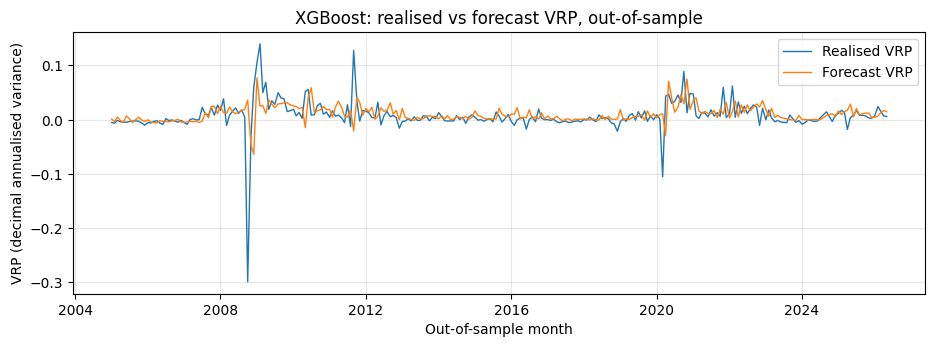

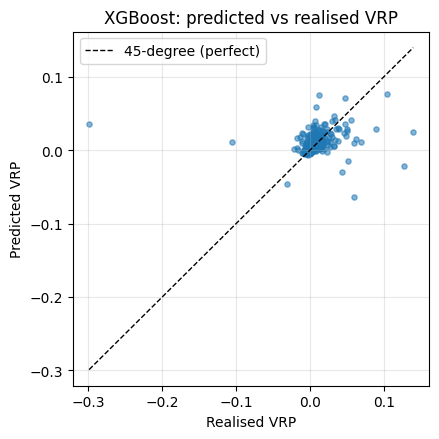

XGBoost: 5 largest absolute-error months (with regime):


,y_true,y_pred,abs_error,regime
2008-10-01,-0.299033,0.036243,0.335276,stressed
2011-09-01,0.127723,-0.020998,0.148721,stressed
2008-12-01,0.059816,-0.063733,0.123550,stressed
2020-03-02,-0.105428,0.010774,0.116202,stressed
2009-02-02,0.139879,0.024987,0.114892,stressed



Cumulative prediction diagnostics (descriptive; QLIKE remains the adjudicating loss):


,model,mean_signed_error,mae,rmse,r2,n_under_predicted,n_over_predicted,worst_regime,worst_regime_mae
0,constant,0.006414,0.016982,0.029940,-0.062140,63,190,stressed,0.037306
1,har,0.001941,0.014755,0.031699,-0.190594,74,179,stressed,0.044353
2,extended_ols,0.002445,0.015538,0.036157,-0.549021,73,180,stressed,0.048458
3,regime_switching,-0.000236,0.016835,0.052303,-2.241397,101,152,stressed,0.063156
4,xgboost,0.002543,0.014124,0.030864,-0.128708,88,165,stressed,0.041108


In [37]:
_ = run_prediction_diagnostic(wf_xgb, "xgboost", diagnostics_rows)

### Per-regime SHAP feature importance (Objective 4)

Objective 4 asks which features drive the forecast in each market state and whether that ranking is stable across states. `mean_abs_shap_by_regime` groups the per-step SHAP values by the regime label at each out-of-sample month and reports mean absolute SHAP per feature within calm, normal, and stressed, plus an all-month column. Mean absolute SHAP is the standard global importance summary; computing it per regime shows where each feature's pull on the prediction concentrates. `shap_rank_changes` then ranks the features within each regime and flags any whose rank is not identical across all three, the direct evidence of regime-dependent feature importance. The output is the OOS month count per regime, the per-regime importance table, and the per-regime ranks with the change flag.

In [38]:
from src.models.xgboost_vrp import mean_abs_shap_by_regime, shap_rank_changes

regimes_oos = dataset.loc[wf_xgb.index, "regime"]
shap_importance_by_regime = mean_abs_shap_by_regime(shap_oos, regimes_oos)
shap_ranks = shap_rank_changes(shap_importance_by_regime)

print("OOS months per regime:")
display(regimes_oos.astype(str).value_counts().rename("n_oos_months").to_frame())
print()
print("Mean absolute SHAP per feature, by regime (Objective 4):")
display(shap_importance_by_regime.round(6))
print()
print("Per-regime importance ranks (1 = most important); rank_changes flags features "
      "whose rank is not identical across calm/normal/stressed:")
display(shap_ranks)
print()

changed = shap_ranks.index[shap_ranks["rank_changes"]].tolist()
stable = shap_ranks.index[~shap_ranks["rank_changes"]].tolist()
print(f"Features whose importance rank changes across regimes: {changed}")
print(f"Features with a stable rank across regimes:            {stable}")

OOS months per regime:


,n_oos_months
regime,
normal,120
calm,92
stressed,41



Mean absolute SHAP per feature, by regime (Objective 4):


,calm,normal,stressed,all
feature,,,,
vix_level,0.001967,0.001246,0.010118,0.002946
cboe_skew,0.001539,0.001229,0.001881,0.001447
vrp_h1m,0.008244,0.005089,0.016073,0.008016
vrp_h3m,0.003979,0.002688,0.002297,0.003094
vrp_h6m,0.001320,0.001674,0.003367,0.001820
realised_skew_21d,0.000632,0.000885,0.001828,0.000946
regime,0.000000,0.000000,0.000000,0.000000



Per-regime importance ranks (1 = most important); rank_changes flags features whose rank is not identical across calm/normal/stressed:


,rank_calm,rank_normal,rank_stressed,rank_changes
feature,,,,
vix_level,3,4,2,True
cboe_skew,4,5,5,True
vrp_h1m,1,1,1,False
vrp_h3m,2,2,4,True
vrp_h6m,5,3,3,True
realised_skew_21d,6,6,6,False
regime,7,7,7,False



Features whose importance rank changes across regimes: ['vix_level', 'cboe_skew', 'vrp_h3m', 'vrp_h6m']
Features with a stable rank across regimes:            ['vrp_h1m', 'realised_skew_21d', 'regime']


### Compare XGBoost to Extended OLS (non-nested; Diebold-Mariano on QLIKE)

XGBoost is not a linear restriction of Extended OLS, so the pair is non-nested and the comparison routes to Diebold-Mariano, not Clark-West (Clark-West is only valid when one model nests the other). Both models are scored through the shared `score_walk_forward`, and the test runs on the paired valid subset, the months where both give a strictly positive implied variance. Diebold-Mariano operates on per-observation QLIKE losses (variance-space, Patton 2011), the same quantity as the reported primary loss, with the Harvey-Leybourne-Newbold small-sample correction. The differential is `loss_xgboost - loss_extended_ols`, so a negative statistic favours XGBoost. The cell reports the paired n, both models' paired-subset QLIKE, the DM statistic, its p-value, and the verdict on whether XGBoost differs significantly from the best linear model.

In [39]:
import numpy as np
import pandas as pd
from src.results import score_walk_forward
from src.metrics import qlike, qlike_per_obs
from src.forecast_comparison import diebold_mariano, is_nested

assert not is_nested("xgboost", "extended_ols"), (
    "('xgboost', 'extended_ols') must be non-nested; XGBoost is not a linear "
    "restriction of Extended OLS, so Diebold-Mariano (not Clark-West) applies"
)

# Score BOTH models through the single shared scorer (no second QLIKE path).
vix_next_xgb = vix_monthly.shift(-1).reindex(wf_xgb.index)
vix_next_extended = vix_monthly.shift(-1).reindex(wf_extended.index)
score_xgb = score_walk_forward(wf_xgb, vix_next_xgb, spy_returns)
score_extended = score_walk_forward(wf_extended, vix_next_extended, spy_returns)

assert wf_xgb.index.equals(wf_extended.index), "OOS windows are not identical"

# Paired subset: months where BOTH models give a valid implied variance.
paired_mask = score_xgb["valid_mask"] & score_extended["valid_mask"]
n_paired = int(paired_mask.sum())

realised_paired = score_xgb["realised_variance_next"][paired_mask]
np.testing.assert_allclose(
    realised_paired, score_extended["realised_variance_next"][paired_mask]
)
implied_xgb_paired = score_xgb["implied_variance"][paired_mask]
implied_extended_paired = score_extended["implied_variance"][paired_mask]

qlike_xgb_paired = qlike(realised_paired, implied_xgb_paired)
qlike_extended_paired = qlike(realised_paired, implied_extended_paired)

print("=== Paired-subset QLIKE (the comparison) ===")
print(f"  XGBoost valid n:    {score_xgb['qlike_n']}  (guard {score_xgb['n_guard_excluded']}, "
      f"nan-tail {score_xgb['n_nan_tail_excluded']})")
print(f"  Extended valid n:   {score_extended['qlike_n']}  (guard {score_extended['n_guard_excluded']}, "
      f"nan-tail {score_extended['n_nan_tail_excluded']})")
print(f"  Paired-subset n:    {n_paired}  (months valid for BOTH models)")
print(f"  QLIKE xgboost:      {qlike_xgb_paired:.6f}")
print(f"  QLIKE extended_ols: {qlike_extended_paired:.6f}")
print(f"  XGBoost lower:      {qlike_xgb_paired < qlike_extended_paired}")
print()

# Diebold-Mariano on per-observation QLIKE losses, HLN-corrected. Non-nested pair.
# d_t = loss_xgboost - loss_extended_ols; a negative statistic favours XGBoost.
loss_xgb_q = qlike_per_obs(realised_paired, implied_xgb_paired)
loss_extended_q = qlike_per_obs(realised_paired, implied_extended_paired)
dm = diebold_mariano(loss_xgb_q, loss_extended_q)

print("=== Diebold-Mariano on QLIKE differentials (paired subset, HLN-corrected) ===")
print(f"  DM statistic:   {dm.statistic:.4f}   (negative favours XGBoost)")
print(f"  p-value:        {dm.p_value:.6f}   (two-sided, t with N-1 df)")
print(f"  HLN correction: {dm.hln_correction}   horizon={dm.horizon}   hac_lag={dm.hac_lag}")
print(f"  N (paired):     {dm.n}")
print(f"  favoured:       {dm.favoured}   (alpha={dm.alpha})")
if dm.favoured == "model_a":
    print(f"  -> XGBoost significantly beats Extended OLS on QLIKE (p={dm.p_value:.6f} < {dm.alpha}).")
elif dm.favoured == "model_b":
    print(f"  -> Extended OLS significantly beats XGBoost on QLIKE (p={dm.p_value:.6f} < {dm.alpha}).")
else:
    print(f"  -> No significant QLIKE difference between XGBoost and Extended OLS "
          f"(p={dm.p_value:.6f} >= {dm.alpha}).")
print()

comparison_table_xgb = pd.DataFrame([
    {"model": "xgboost",
     "QLIKE_full": round(score_xgb["qlike"], 6), "QLIKE_full_n": score_xgb["qlike_n"],
     "QLIKE_paired": round(qlike_xgb_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_xgb["mse"], 8)},
    {"model": "extended_ols",
     "QLIKE_full": round(score_extended["qlike"], 6), "QLIKE_full_n": score_extended["qlike_n"],
     "QLIKE_paired": round(qlike_extended_paired, 6), "QLIKE_paired_n": n_paired,
     "MSE_full": round(score_extended["mse"], 8)},
])
print("Comparison table  (QLIKE_full / MSE_full = descriptive per-model; "
      "QLIKE_paired = comparison subset):")
display(comparison_table_xgb)
print()

assert dm.test_type == "diebold_mariano" and dm.hln_correction
assert dm.n == n_paired
assert n_paired <= min(score_xgb["qlike_n"], score_extended["qlike_n"])
print("Assertions passed: Diebold-Mariano (HLN) adjudicates the non-nested XGBoost vs "
      "Extended OLS pair on QLIKE; paired n stated.")

=== Paired-subset QLIKE (the comparison) ===
  XGBoost valid n:    243  (guard 9, nan-tail 1)
  Extended valid n:   249  (guard 3, nan-tail 1)
  Paired-subset n:    242  (months valid for BOTH models)
  QLIKE xgboost:      0.429218
  QLIKE extended_ols: 2.432373
  XGBoost lower:      True

=== Diebold-Mariano on QLIKE differentials (paired subset, HLN-corrected) ===
  DM statistic:   -1.0298   (negative favours XGBoost)
  p-value:        0.304154   (two-sided, t with N-1 df)
  HLN correction: True   horizon=1   hac_lag=0
  N (paired):     242
  favoured:       tie   (alpha=0.05)
  -> No significant QLIKE difference between XGBoost and Extended OLS (p=0.304154 >= 0.05).

Comparison table  (QLIKE_full / MSE_full = descriptive per-model; QLIKE_paired = comparison subset):


,model,QLIKE_full,QLIKE_full_n,QLIKE_paired,QLIKE_paired_n,MSE_full
0,xgboost,0.461875,243,0.429218,242,0.000953
1,extended_ols,2.375025,249,2.432373,242,0.001307



Assertions passed: Diebold-Mariano (HLN) adjudicates the non-nested XGBoost vs Extended OLS pair on QLIKE; paired n stated.


### Mincer-Zarnowitz rationality test of VIX (Objective 1)

This cell tests whether VIX is a rational forecast of the realised variance that follows it, by regressing the forward realised variance on the risk-neutral variance, realised_variance(t+1) = alpha + beta * VIX_variance(t), on the full sample and separately within each regime defined by VIX at month t. A rational forecast implies the joint restriction alpha = 0 and beta = 1, tested with a Wald statistic built from Newey-West HAC standard errors using the locked automatic lag rule computed from each regression's own sample size. The realised side is the same forward-looking, uncentred target used on the realised side of QLIKE (src.har_rv.realised_variance_target), not the backward compute_realised_vol series, so the outcome is the variance VIX(t) was actually predicting. Read the table for beta relative to 1 and the Wald p-value against the config significance level: rejection means VIX is not a rational forecast for that sample. This is a rationality test of VIX, independent of the model sequence, and is never scored on QLIKE.

In [40]:
import numpy as np
from src.vrp import resample_to_month_start
from src.har_rv import realised_variance_target
from src.mincer_zarnowitz import run_mincer_zarnowitz, mz_results_table

mz_results, mz_frame = run_mincer_zarnowitz(vix_monthly, spy_returns)
mz_table = mz_results_table(mz_results)

# Readable display copy. Every value comes from mz_table, no hardcoded literals.
mz_display = mz_table.set_index("sample").rename(columns={
    "se_alpha": "SE(alpha)",
    "se_beta": "SE(beta)",
    "wald_stat": "Wald stat",
    "wald_p": "Wald p-value",
    "reject_rationality": "reject H0",
})
for col in ["alpha", "SE(alpha)", "beta", "SE(beta)", "Wald stat"]:
    mz_display[col] = mz_display[col].round(4)
mz_display["Wald p-value"] = mz_display["Wald p-value"].map(lambda p: f"{p:.3e}")
display(mz_display)

print(f"MZ sample span: {mz_frame.index.min().date()} -> {mz_frame.index.max().date()}  (n={len(mz_frame)})")
regime_n = mz_frame["regime"].astype(str).value_counts().reindex(config.REGIME_LABELS)
print("Per-regime n:", {k: int(v) for k, v in regime_n.items()})

# Hard assert of the corrected pairing: the realised leg at t is the forward
# estimator evaluated AT t (the window VIX(t) prices), and is not the shifted
# t+1 series, which would reach one month too far.
_target_monthly = resample_to_month_start(realised_variance_target(spy_returns))
np.testing.assert_allclose(
    mz_frame["realised_variance_next"].to_numpy(),
    _target_monthly.reindex(mz_frame.index).to_numpy(),
)
_shifted = _target_monthly.shift(-1).reindex(mz_frame.index).to_numpy()
assert not np.allclose(
    mz_frame["realised_variance_next"].to_numpy(), _shifted, equal_nan=True
), "realised leg matches the t+1-shifted series; corrected pairing violated"
print("Realised leg == realised_variance_target at t (hard assert); != the t+1-shifted series: OK")

,alpha,SE(alpha),beta,SE(beta),Wald stat,Wald p-value,n,reject H0
sample,,,,,,,,
full,-0.0002,0.0043,0.7865,0.1390,9.7011,7.824e-03,400,True
calm,0.0028,0.0038,0.5593,0.2348,21.6368,2.003e-05,131,True
normal,-0.0116,0.0065,1.0290,0.1968,56.9897,4.215e-13,198,True
stressed,0.0216,0.0220,0.6535,0.2136,2.7794,2.491e-01,71,False


MZ sample span: 1993-02-01 -> 2026-05-01  (n=400)
Per-regime n: {'calm': 131, 'normal': 198, 'stressed': 71}
Realised leg == realised_variance_target at t (hard assert); != the t+1-shifted series: OK


### Regime-conditional model comparison (Objective 3)

This cell repeats the four validated pairwise comparisons within each market regime classified at the decision date t, to test whether any model's QLIKE advantage is concentrated in one market state rather than spread evenly across the sample. Each pair is sliced to the months where both models give a strictly positive implied variance and that carry the regime label at time t, then routed through the same dispatcher as the full-sample cells: bootstrap Clark-West on QLIKE for the three nested pairs and Diebold-Mariano with the HLN correction for the non-nested XGBoost versus Extended OLS pair. The stressed regime has about 41 out-of-sample months, below the LOW_POWER_MIN_N floor, so its p-values are flagged low_power and read as descriptive rather than decisive. The three tables show each model's QLIKE per regime on a common-valid subset, the per-pair test result per regime, and a decomposition of XGBoost's stressed-regime QLIKE quantifying how much of the mean comes from the single worst month. Read the winner and low_power columns alongside the SHAP regime finding and the Mincer-Zarnowitz regime finding: regimes differ in which features matter and in VIX rationality, but regime-specific coefficients do not turn that into a forecast gain.

In [41]:
from src.regime_comparison import (
    compare_models_by_regime,
    per_regime_paired_qlike,
    regime_qlike_decomposition,
)
from src.results import score_walk_forward
from src import config

# All five fitted walk-forward frames, sharing the one OOS index.
wf_frames = {
    "constant": wf_constant,
    "har": wf_har,
    "extended_ols": wf_extended,
    "regime_switching": wf_regime_ols,
    "xgboost": wf_xgb,
}
# The four pairs the full-sample comparison cells validated, in (smaller, larger)
# nesting order; the last is non-nested and routes to Diebold-Mariano.
pairs = [
    ("constant", "har"),
    ("har", "extended_ols"),
    ("extended_ols", "regime_switching"),
    ("xgboost", "extended_ols"),
]

# (a) Per-regime per-model QLIKE on the common-valid subset across all models.
regime_model_qlike = per_regime_paired_qlike(wf_frames, vix_monthly, spy_returns, dataset)
print("Per-regime per-model QLIKE (common-valid subset across all models; "
      "all_regimes = full OOS):")
display(regime_model_qlike.round(6))
print()

# (b) Per-regime per-pair tests, routed by is_nested. winner is the lower raw
# paired QLIKE (QLIKE-primary), never the CW/DM test direction;
# cw_qlike_direction_conflict flags rows where the test points the other way.
regime_tests = compare_models_by_regime(wf_frames, vix_monthly, spy_returns, dataset, pairs)
report_cols = [
    "regime", "pair", "test_type", "n_paired",
    "qlike_smaller", "qlike_larger", "statistic", "p_value",
    "winner", "low_power", "cw_qlike_direction_conflict",
]
print("Per-regime per-pair tests (nested -> bootstrap Clark-West on QLIKE; "
      "non-nested -> Diebold-Mariano HLN on QLIKE; winner = lower raw paired QLIKE; "
      f"low_power flags n_paired < {config.LOW_POWER_MIN_N}):")
display(regime_tests[report_cols].round(6))
print()

# (c) Stressed-regime XGBoost QLIKE decomposition.
stressed_xgb_decomp = regime_qlike_decomposition(
    wf_xgb, vix_monthly, spy_returns, dataset,
    regime_label="stressed", model_name="xgboost",
)
print("Stressed-regime XGBoost QLIKE decomposition (full mean vs median per-obs; "
      "single-largest-month share and that month):")
display(stressed_xgb_decomp)
print()

# Sanity: per pair the three regime n_paired partition the full paired subset.
for m_a, m_b in pairs:
    score_a = score_walk_forward(
        wf_frames[m_a], vix_monthly.shift(-1).reindex(wf_frames[m_a].index), spy_returns
    )
    score_b = score_walk_forward(
        wf_frames[m_b], vix_monthly.shift(-1).reindex(wf_frames[m_b].index), spy_returns
    )
    full_paired = int((score_a["valid_mask"] & score_b["valid_mask"]).sum())
    by_regime = int(regime_tests.loc[regime_tests["pair"] == f"{m_a} vs {m_b}", "n_paired"].sum())
    assert by_regime == full_paired, (m_a, m_b, by_regime, full_paired)
print("Assertions passed: per pair, regime n_paired partition the full paired subset.")

Per-regime per-model QLIKE (common-valid subset across all models; all_regimes = full OOS):


,constant,har,extended_ols,regime_switching,xgboost,n_paired
regime,,,,,,
calm,2.706141,0.356878,0.287168,0.326477,0.344008,63
normal,1.161233,0.498750,0.565961,0.453593,0.414736,112
stressed,0.253442,0.253539,0.251207,3.387061,0.433590,35
all_regimes,1.473407,0.415320,0.429864,0.904370,0.396660,210


Per-regime per-pair tests (nested -> bootstrap Clark-West on QLIKE; non-nested -> Diebold-Mariano HLN on QLIKE; winner = lower raw paired QLIKE; low_power flags n_paired < 50):

,regime,pair,test_type,n_paired,qlike_smaller,qlike_larger,statistic,p_value,winner,low_power,cw_qlike_direction_conflict
0,calm,constant vs har,clark_west_bootstrap,65,2.825671,0.358017,2.818238,0.005700,har,False,False
1,normal,constant vs har,clark_west_bootstrap,117,1.124870,0.499603,1.931367,0.050400,har,False,False
2,stressed,constant vs har,clark_west_bootstrap,40,0.259544,0.417762,0.893939,0.221600,constant,True,False
3,calm,har vs extended_ols,clark_west_bootstrap,92,0.367166,0.288445,1.987064,0.030000,extended_ols,False,False
4,normal,har vs extended_ols,clark_west_bootstrap,118,0.481037,0.542351,-0.034345,0.566900,har,False,False
5,stressed,har vs extended_ols,clark_west_bootstrap,39,0.355943,12.842225,-1.027342,0.899300,har,True,False
6,calm,extended_ols vs regime_switching,clark_west_bootstrap,92,0.288445,0.330769,1.782410,0.028400,extended_ols,False,True
7,normal,extended_ols vs regime_switching,clark_west_bootstrap,118,0.542351,0.433876,1.176322,0.102400,regime_switching,False,False
8,stressed,extended_ols vs regime_switching,clark_west_bootstrap,36,0.277045,3.315619,0.989436,0.224300,extended_ols,True,False
9,calm,xgboost vs extended_ols,diebold_mariano,90,0.312530,0.282111,1.186289,0.238665,extended_ols,False,False



Stressed-regime XGBoost QLIKE decomposition (full mean vs median per-obs; single-largest-month share and that month):


,model,regime,n,full_mean_qlike,median_per_obs_qlike,largest_month_qlike_share,largest_month_date,largest_month_regime
0,xgboost,stressed,38,0.742423,0.200914,0.431004,2022-03-01,stressed



Assertions passed: per pair, regime n_paired partition the full paired subset.


### Circle 3A position series

The next cell builds the monthly short-vol position series for both Circle 3A strategies from the HAR walk-forward forecast, which drives the base rule; the Extended OLS driven run is computed alongside and reported as the named variant, since every computed variant is reported. The naive strategy shorts volatility at month t when the one-month-ahead VRP forecast exceeds the expanding-window median of past forecasts up to and including t; the conditioned strategy adds the requirement that the VIX-threshold regime at t is not stressed, a label built from the VIX level at t and so knowable at entry. Both quantities at t use only data with index <= t, so no forward information enters the positions; the realised side enters only in the P&L cell. The output shows the base-rule position frame head and tail plus a counts table for both drivers, where each conditioned strategy shorts in no more months than its naive counterpart and is flat in every stressed month.

In [42]:
from src.circle3a.positions import build_position_series

# Base rule driver: HAR. Extended OLS retained as the reported variant.
positions = build_position_series(wf_har["y_pred"], dataset.loc[wf_har.index, "regime"])
positions_extended = build_position_series(wf_extended["y_pred"], dataset.loc[wf_extended.index, "regime"])


def _position_counts(pos_frame, driver):
    n_months = len(pos_frame)
    n_naive = int(pos_frame["position_naive"].sum())
    n_cond = int(pos_frame["position_conditioned"].sum())
    return {"driver": driver, "n_months": n_months, "n_short_naive": n_naive,
            "n_short_conditioned": n_cond, "n_gated_out": n_naive - n_cond}


strategy_counts = pd.DataFrame([
    _position_counts(positions, "har (base rule)"),
    _position_counts(positions_extended, "extended_ols (variant)"),
]).set_index("driver")

display(positions.head())
display(positions.tail())
display(strategy_counts)

for frame in (positions, positions_extended):
    stressed = frame["regime"].astype(str) == config.REGIME_STRESSED_LABEL
    assert int(frame.loc[stressed, "position_conditioned"].sum()) == 0
    assert int((frame["position_conditioned"] <= frame["position_naive"]).all())
print("Conditioned strategy flat in every stressed month and never shorts more than naive, both drivers: OK")

,forecast,expanding_median,regime,position_naive,position_conditioned
2005-01-03,0.008048,0.008048,calm,0,0
2005-02-01,0.003808,0.005928,calm,0,0
2005-03-01,0.002776,0.003808,calm,0,0
2005-04-01,0.005234,0.004521,calm,1,1
2005-05-02,0.002971,0.003808,normal,0,0


,forecast,expanding_median,regime,position_naive,position_conditioned
2026-01-02,0.008964,0.009409,calm,0,0
2026-02-02,0.009841,0.009415,normal,1,1
2026-03-02,0.015383,0.009421,normal,1,1
2026-04-01,0.012681,0.009492,normal,1,1
2026-05-01,0.009911,0.009564,normal,1,1


,n_months,n_short_naive,n_short_conditioned,n_gated_out
driver,,,,
har (base rule),253,129,96,33
extended_ols (variant),253,124,89,35


Conditioned strategy flat in every stressed month and never shorts more than naive, both drivers: OK


### Circle 3A variance-swap P&L

The next cell computes the synthetic variance-swap P&L for both strategies and both drivers from the position frames, reusing the same forward realised-variance target that scores the models rather than a second estimator. A short position entered at month t receives the variance strike set by the entry-month VIX and pays the variance realised over the forward window that strike prices (the window the locked spec writes as t+1), so the monthly payoff equals the realised VRP by construction. Costs are proportional to the entry-month variance strike and charged on every position change, including gate-exit closes when the regime turns stressed, and are reported at the base haircut and the stress multiple. Months whose forward realised window is not fully in sample are dropped and counted; on the locked snapshot none are. The totals table carries the base-rule (HAR-driven) rows and the disclosed Extended OLS variant rows.

In [43]:
from src.circle3a.pnl import build_pnl_frame

pnl = build_pnl_frame(positions, vix_monthly, spy_returns)
pnl_extended = build_pnl_frame(positions_extended, vix_monthly, spy_returns)

pnl_totals = pd.DataFrame(
    [
        {"driver": "har (base rule)", "strategy": "naive",
         "total_net_base": pnl["net_naive_base"].sum(),
         "total_net_stress": pnl["net_naive_stress"].sum()},
        {"driver": "har (base rule)", "strategy": "conditioned",
         "total_net_base": pnl["net_conditioned_base"].sum(),
         "total_net_stress": pnl["net_conditioned_stress"].sum()},
        {"driver": "extended_ols (variant)", "strategy": "naive",
         "total_net_base": pnl_extended["net_naive_base"].sum(),
         "total_net_stress": pnl_extended["net_naive_stress"].sum()},
        {"driver": "extended_ols (variant)", "strategy": "conditioned",
         "total_net_base": pnl_extended["net_conditioned_base"].sum(),
         "total_net_stress": pnl_extended["net_conditioned_stress"].sum()},
    ]
).set_index(["driver", "strategy"])

display(pnl.tail())
display(pnl_totals)
print(f"months retained: base rule {len(pnl)} (nan-dropped {pnl.attrs['n_nan_dropped']}), "
      f"variant {len(pnl_extended)} (nan-dropped {pnl_extended.attrs['n_nan_dropped']})")

,payoff,position_naive,position_conditioned,gross_naive,gross_conditioned,net_naive_base,net_conditioned_base,net_naive_stress,net_conditioned_stress
2026-01-02,0.010195,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-02-02,0.010076,1,1,0.010076,0.010076,0.009809,0.009809,0.009542,0.009542
2026-03-02,0.011270,1,1,0.011270,0.011270,0.011270,0.011270,0.011270,0.011270
2026-04-01,0.042239,1,1,0.042239,0.042239,0.042239,0.042239,0.042239,0.042239
2026-05-01,0.018669,1,1,0.018669,0.018669,0.018669,0.018669,0.018669,0.018669


total_net_base  total_net_stress
driver                 strategy                                     
har (base rule)        naive              1.504485          1.469964
                       conditioned        0.761661          0.731099
extended_ols (variant) naive              0.826296          0.794496
                       conditioned        0.773850          0.745591

months retained: base rule 253 (nan-dropped 0), variant 253 (nan-dropped 0)


### All ten pairwise model comparisons

The model sequence compares each model against its immediate predecessor, which covers four of the ten possible pairs. The next cell computes all ten from the persisted per-observation arrays under outputs/, so the full comparison matrix is available on one convention rather than four. Routing is by nesting: nested pairs go to the bootstrap Clark-West on per-observation QLIKE with the config seed and replications, non-nested pairs to Diebold-Mariano with the Harvey-Leybourne-Newbold correction. The pairs already computed in the model sequence reproduce their earlier values, which is the check that the persisted arrays and the live cells agree.

In [2]:
import numpy as np
import pandas as pd
from src import config
from src.forecast_comparison import clark_west_bootstrap, diebold_mariano, is_nested
from src.metrics import qlike_per_obs

_outputs = config.PROJECT_ROOT / "outputs"
_combined = np.load(_outputs / "nested_inputs_combined.npz")
_xgb_npz = np.load(_outputs / "nested_inputs_xgboost.npz")
_corrected = np.load(_outputs / "corrected_cw_results.npz")

_fields = ("implied_variance", "realised_variance_next", "qlike_per_obs", "valid_mask")
arrays_by_model = {str(_m): {_f: _combined[f"{_m}__{_f}"] for _f in _fields}
                   for _m in _combined["models"]}
arrays_by_model["xgboost"] = {_f: _xgb_npz[_f] for _f in _fields}
assert list(_xgb_npz["date"]) == list(_combined["date"]), "OOS date axis mismatch"

# Ten stage-1 pairs. Nested pairs are listed (smaller, larger) and route to the
# bootstrap Clark-West on QLIKE with the config seed and replications; non-nested
# pairs route to Diebold-Mariano with the HLN correction on per-obs QLIKE. The
# pair (xgboost, extended_ols) keeps the cell 76 orientation. The source column
# names the cell or artifact carrying the pair, or marks the row as computed
# here.
pair_specs = [
    ("constant", "har", "cell 48; nested_inputs_metadata.json; corrected_cw_results.npz"),
    ("constant", "extended_ols", "computed here"),
    ("constant", "regime_switching", "computed here"),
    ("constant", "xgboost", "computed here"),
    ("har", "extended_ols", "cell 56; nested_inputs_metadata.json"),
    ("har", "regime_switching", "computed here"),
    ("har", "xgboost", "computed here"),
    ("extended_ols", "regime_switching", "cell 64; nested_inputs_metadata.json"),
    ("xgboost", "extended_ols", "cell 76"),
    ("regime_switching", "xgboost", "computed here"),
]

rows = []
for _a, _b, _source in pair_specs:
    _pm = arrays_by_model[_a]["valid_mask"] & arrays_by_model[_b]["valid_mask"]
    if is_nested(_a, _b):
        _rv = arrays_by_model[_a]["realised_variance_next"][_pm]
        _iv_s = arrays_by_model[_a]["implied_variance"][_pm]
        _iv_l = arrays_by_model[_b]["implied_variance"][_pm]
        _res = clark_west_bootstrap(
            qlike_per_obs(_rv, _iv_s), qlike_per_obs(_rv, _iv_l),
            qlike_per_obs(_iv_s, _iv_l), loss="qlike",
        )
    else:
        _res = diebold_mariano(arrays_by_model[_a]["qlike_per_obs"][_pm],
                               arrays_by_model[_b]["qlike_per_obs"][_pm])
    rows.append({"pair": f"{_a} vs {_b}", "test": _res.test_type,
                 "statistic": _res.statistic, "p_value": _res.p_value,
                 "n_paired": _res.n, "source": _source})

addendum_pairwise = pd.DataFrame(rows)

corrected_cw_constant_har = {
    "statistic": float(_corrected["constant__har__s_obs"]),
    "p_corrected": float(_corrected["constant__har__p_corrected"]),
    "n_paired": int(_corrected["constant__har__n_paired_observed"]),
}
print("Sign convention: nested rows are (smaller, larger); a positive Clark-West "
      "statistic favours the larger model.")
print("Non-nested rows test d_t = QLIKE(first listed) - QLIKE(second listed); a "
      "negative DM statistic favours the first listed model.")
print(f"Corrected Clark-West, constant vs har, quoted from corrected_cw_results.npz: "
      f"statistic={corrected_cw_constant_har['statistic']:.6f}, "
      f"p={corrected_cw_constant_har['p_corrected']:.6f}, "
      f"n={corrected_cw_constant_har['n_paired']}")
print(f"Ten-pair table ({len(addendum_pairwise)} rows); newly computed rows are "
      f"marked 'computed here' in source:")
display(addendum_pairwise)

Sign convention: nested rows are (smaller, larger); a positive Clark-West statistic favours the larger model.
Non-nested rows test d_t = QLIKE(first listed) - QLIKE(second listed); a negative DM statistic favours the first listed model.
Corrected Clark-West, constant vs har, quoted from corrected_cw_results.npz: statistic=2.036300, p=0.005701, n=222
Ten-pair table (10 rows); newly computed rows are marked 'computed here' in source:


,pair,test,statistic,p_value,n_paired,source
0,constant vs har,clark_west_bootstrap,3.465788,0.004100,222,cell 48; nested_inputs_metadata.json; correcte...
1,constant vs extended_ols,clark_west_bootstrap,-0.043986,0.558100,220,computed here
2,constant vs regime_switching,diebold_mariano,1.002581,0.317180,218,computed here
3,constant vs xgboost,diebold_mariano,2.535239,0.011955,214,computed here
4,har vs extended_ols,clark_west_bootstrap,-0.982124,0.790000,249,cell 56; nested_inputs_metadata.json
5,har vs regime_switching,diebold_mariano,-0.962853,0.336567,247,computed here
6,har vs xgboost,diebold_mariano,-0.443343,0.657914,243,computed here
7,extended_ols vs regime_switching,clark_west_bootstrap,1.287212,0.098100,246,cell 64; nested_inputs_metadata.json
8,xgboost vs extended_ols,diebold_mariano,-1.029762,0.304154,242,cell 76
9,regime_switching vs xgboost,diebold_mariano,0.960633,0.337708,240,computed here


### Regime-conditional comparison for all four model pairs

Nothing is refit here and no free parameter is chosen: every number below is read from a persisted array under outputs/ or is arithmetic on those arrays. The next cell rebuilds the Objective 3 regime-conditional table for all four pairs from the persisted per-observation arrays through the same routing used in the model sequence, and prints the partition reconciliation so the regime subsets are shown to sum to the paired out-of-sample window. The fourth pair is xgboost against extended_ols; no xgboost against har pair exists in this design.

In [44]:
import numpy as np
import pandas as pd
from src import config
from src.forecast_comparison import clark_west_bootstrap, diebold_mariano, is_nested
from src.metrics import qlike, qlike_per_obs

_out = config.PROJECT_ROOT / "outputs"
_combined = np.load(_out / "nested_inputs_combined.npz")
_xgb = np.load(_out / "nested_inputs_xgboost.npz")
_fields = ("implied_variance", "realised_variance_next", "qlike_per_obs", "valid_mask")
arrays = {str(_m): {_f: _combined[f"{_m}__{_f}"] for _f in _fields} for _m in _combined["models"]}
arrays["xgboost"] = {_f: _xgb[_f] for _f in _fields}
oos_dates = pd.DatetimeIndex(_combined["date"])
regime_at_t = _combined["regime_at_t"].astype(str)
assert list(_xgb["date"]) == list(_combined["date"]), "OOS date axis mismatch"

# The four Objective 3 pairs, nested pairs listed (smaller, larger). The fourth
# pair is xgboost vs extended_ols. No xgboost vs har pair exists in this design.
stage3_pairs = [
    ("constant", "har"),
    ("har", "extended_ols"),
    ("extended_ols", "regime_switching"),
    ("xgboost", "extended_ols"),
]

_rows = []
for _a, _b in stage3_pairs:
    _both = arrays[_a]["valid_mask"] & arrays[_b]["valid_mask"]
    for _regime in config.REGIME_LABELS:
        _s = (regime_at_t == _regime) & _both
        _rv = arrays[_a]["realised_variance_next"][_s]
        np.testing.assert_allclose(_rv, arrays[_b]["realised_variance_next"][_s])
        _ia, _ib = arrays[_a]["implied_variance"][_s], arrays[_b]["implied_variance"][_s]
        _qa, _qb = qlike(_rv, _ia), qlike(_rv, _ib)
        _la, _lb = qlike_per_obs(_rv, _ia), qlike_per_obs(_rv, _ib)
        if is_nested(_a, _b):
            _res = clark_west_bootstrap(_la, _lb, qlike_per_obs(_ia, _ib), loss="qlike")
            _block, _direction = _res.block_length, (_b if _res.larger_model_wins else "none")
        else:
            _res = diebold_mariano(_la, _lb)
            _block = pd.NA
            _direction = {"model_a": _a, "model_b": _b, "tie": "none"}[_res.favoured]
        _winner = _a if _qa < _qb else (_b if _qb < _qa else "none")
        _rows.append({
            "regime": _regime, "pair": f"{_a} vs {_b}", "test_type": _res.test_type,
            "n_paired": int(_s.sum()), "qlike_smaller": _qa, "qlike_larger": _qb,
            "statistic": _res.statistic, "p_value": _res.p_value, "block_length": _block,
            "winner": _winner, "low_power": int(_s.sum()) < config.LOW_POWER_MIN_N,
            "cw_qlike_direction_conflict": _direction != "none" and _direction != _winner,
        })

stage3_table = pd.DataFrame(_rows)
display(stage3_table)

partition = pd.DataFrame([
    {"pair": f"{_a} vs {_b}",
     "sum_regime_n": int(stage3_table.loc[stage3_table["pair"] == f"{_a} vs {_b}", "n_paired"].sum()),
     "full_paired_n": int((arrays[_a]["valid_mask"] & arrays[_b]["valid_mask"]).sum())}
    for _a, _b in stage3_pairs
])
partition["exact"] = partition["sum_regime_n"] == partition["full_paired_n"]
display(partition)
print(f"partition exact for all {len(partition)} pairs: {bool(partition['exact'].all())}")

,regime,pair,test_type,n_paired,qlike_smaller,qlike_larger,statistic,p_value,block_length,winner,low_power,cw_qlike_direction_conflict
0,calm,constant vs har,clark_west_bootstrap,65,2.825671,0.358017,2.818238,0.005700,4,har,False,False
1,normal,constant vs har,clark_west_bootstrap,117,1.124870,0.499603,1.931367,0.050400,4,har,False,False
2,stressed,constant vs har,clark_west_bootstrap,40,0.259544,0.417762,0.893939,0.221600,3,constant,True,False
3,calm,har vs extended_ols,clark_west_bootstrap,92,0.367166,0.288445,1.987064,0.030000,4,extended_ols,False,False
4,normal,har vs extended_ols,clark_west_bootstrap,118,0.481037,0.542351,-0.034345,0.566900,4,har,False,False
5,stressed,har vs extended_ols,clark_west_bootstrap,39,0.355943,12.842225,-1.027342,0.899300,3,har,True,False
6,calm,extended_ols vs regime_switching,clark_west_bootstrap,92,0.288445,0.330769,1.782410,0.028400,4,extended_ols,False,True
7,normal,extended_ols vs regime_switching,clark_west_bootstrap,118,0.542351,0.433876,1.176322,0.102400,4,regime_switching,False,False
8,stressed,extended_ols vs regime_switching,clark_west_bootstrap,36,0.277045,3.315619,0.989436,0.224300,3,extended_ols,True,False
9,calm,xgboost vs extended_ols,diebold_mariano,90,0.312530,0.282111,1.186289,0.238665,<NA>,extended_ols,False,False


,pair,sum_regime_n,full_paired_n,exact
0,constant vs har,222,222,True
1,har vs extended_ols,249,249,True
2,extended_ols vs regime_switching,246,246,True
3,xgboost vs extended_ols,242,242,True


partition exact for all 4 pairs: True


### Per-model QLIKE decomposition and the denominator case

The next cell displays, for each of the five models, the full-sample mean QLIKE on its valid months, the mean excluding that model's single largest per-observation contributor, the median per-observation value, and the anchor month with its share of the summed loss. It then traces the Extended OLS anchor month across both loss surfaces, and reports the cross-model relationship between implied variance and per-observation QLIKE. The anchor month is taken as the argmax of the Extended OLS per-observation series rather than written as a literal, so the trace follows the data.

In [45]:
from scipy.stats import spearmanr
from src.data_loader import download_prices
from src.returns import compute_log_returns
from src.vrp import resample_to_month_start

model_order = ["constant", "har", "extended_ols", "regime_switching", "xgboost"]

_rows = []
for _m in model_order:
    _v = arrays[_m]["valid_mask"]
    _q = arrays[_m]["qlike_per_obs"][_v]
    _d = oos_dates[_v]
    _j = int(np.argmax(_q))
    _rows.append({
        "model": _m, "n_valid": int(_v.sum()), "qlike_full": _q.mean(),
        "qlike_ex_largest": (_q.sum() - _q[_j]) / (len(_q) - 1),
        "median_per_obs": float(np.median(_q)),
        "anchor_month": _d[_j].date().isoformat(),
        "anchor_share_pct": 100.0 * _q[_j] / _q.sum(),
    })
ladder_decomposition = pd.DataFrame(_rows)
display(ladder_decomposition)

# Anchor month of the Extended OLS ladder row, taken from the data rather than
# written as a literal, then traced across both loss surfaces.
_ext_valid = arrays["extended_ols"]["valid_mask"]
case_month = oos_dates[_ext_valid][int(np.argmax(arrays["extended_ols"]["qlike_per_obs"][_ext_valid]))]
_i = int(np.where(oos_dates == case_month)[0][0])

vix_monthly_addendum = resample_to_month_start(download_prices(config.TICKER_VIX)["close"])
spy_returns_addendum = compute_log_returns(download_prices(config.TICKER_SPY))
vix_t = vix_monthly_addendum.reindex(oos_dates)
vix_next = vix_monthly_addendum.shift(-1).reindex(oos_dates)
variance_strike = float(vix_next.iloc[_i]) ** 2 / config.VIX_VARIANCE_SCALE

_rows = []
for _m in ("extended_ols", "har"):
    _v = arrays[_m]["valid_mask"]
    _q = arrays[_m]["qlike_per_obs"]
    _se = (_combined[f"{_m}__vrp_forecast"] - _combined[f"{_m}__vrp_realised"]) ** 2
    _sef = _se[np.isfinite(_se)]
    _rows.append({
        "model": _m, "per_obs_qlike": _q[_i],
        "qlike_rank": int((_q[_v] > _q[_i]).sum()) + 1, "qlike_n": int(_v.sum()),
        "share_of_summed_qlike_pct": 100.0 * _q[_i] / _q[_v].sum(),
        "squared_error": _se[_i], "sq_err_rank": int((_sef > _se[_i]).sum()) + 1,
        "sq_err_n": len(_sef), "ratio_to_overall_mse": _se[_i] / _sef.mean(),
        "implied_variance": arrays[_m]["implied_variance"][_i],
        "pct_of_variance_strike": 100.0 * arrays[_m]["implied_variance"][_i] / variance_strike,
    })
case_frame = pd.DataFrame(_rows)
print(f"Case month {case_month.date()}: VIX(t)={float(vix_t.iloc[_i]):.2f}, "
      f"VIX(t+1)={float(vix_next.iloc[_i]):.2f}, variance strike={variance_strike:.8f}")
display(case_frame)

_q_all = np.vstack([arrays[_m]["qlike_per_obs"] for _m in model_order])
_iv_all = np.vstack([arrays[_m]["implied_variance"] for _m in model_order])
_fq, _fi = _q_all.ravel(), _iv_all.ravel()
_ok = np.isfinite(_fq) & np.isfinite(_fi)
_rho_iv = spearmanr(_fi[_ok], _fq[_ok])
# Months where every model is guard-excluded carry no per-obs QLIKE and are
# dropped, not zero-filled, so the correlation runs on months that have a value.
_finite = np.isfinite(_q_all)
_max_q = np.full(_q_all.shape[1], np.nan)
_has_any = _finite.any(axis=0)
_max_q[_has_any] = np.nanmax(np.where(_finite, _q_all, -np.inf), axis=0)[_has_any]
_vix_drop = -(vix_next.to_numpy() - vix_t.to_numpy()) / vix_t.to_numpy()
_g = np.isfinite(_max_q) & np.isfinite(_vix_drop)
_rho_drop = spearmanr(_vix_drop[_g], _max_q[_g])
print(f"Spearman(implied variance, per-obs QLIKE) over model-months: "
      f"rho={_rho_iv.statistic:.4f}, p={_rho_iv.pvalue:.3e}, n={int(_ok.sum())}")
print(f"Spearman(VIX drop t to t+1, max per-obs QLIKE across models): "
      f"rho={_rho_drop.statistic:.4f}, p={_rho_drop.pvalue:.3e}, n={int(_g.sum())}")

_o = np.argsort(-_fq[_ok])[:10]
_mi = np.repeat(np.arange(len(model_order)), len(oos_dates))[_ok][_o]
_di = np.tile(np.arange(len(oos_dates)), len(model_order))[_ok][_o]
largest_qlike = pd.DataFrame({
    "model": [model_order[_k] for _k in _mi],
    "date": [oos_dates[_k].date().isoformat() for _k in _di],
    "per_obs_qlike": _fq[_ok][_o], "implied_variance": _fi[_ok][_o],
    "regime_at_t": [regime_at_t[_k] for _k in _di],
})
display(largest_qlike)
print(f"constant rows: {int((largest_qlike['model'] == 'constant').sum())} of {len(largest_qlike)}; "
      f"max implied variance in the ten: {largest_qlike['implied_variance'].max():.5f}")

,model,n_valid,qlike_full,qlike_ex_largest,median_per_obs,anchor_month,anchor_share_pct
0,constant,223,1.462384,1.233105,0.178386,2006-06-01,16.056541
1,har,251,0.435924,0.398022,0.124641,2015-07-01,9.058319
2,extended_ols,249,2.375025,0.438470,0.143741,2022-03-01,81.612452
3,regime_switching,247,0.814857,0.399212,0.148358,2009-01-02,51.206720
4,xgboost,243,0.461875,0.413537,0.159259,2022-03-01,10.833920


Case month 2022-03-01: VIX(t)=33.32, VIX(t+1)=19.63, variance strike=0.03853369


,model,per_obs_qlike,qlike_rank,qlike_n,share_of_summed_qlike_pct,squared_error,sq_err_rank,sq_err_n,ratio_to_overall_mse,implied_variance,pct_of_variance_strike
0,extended_ols,482.640629,1,249,81.612452,0.001156,21,253,0.884343,0.000128,0.332240
1,har,3.657660,7,251,3.342867,0.000602,29,253,0.598998,0.009596,24.904016


Spearman(implied variance, per-obs QLIKE) over model-months: rho=-0.0583, p=4.251e-02, n=1213
Spearman(VIX drop t to t+1, max per-obs QLIKE across models): rho=0.1829, p=3.576e-03, n=252


,model,date,per_obs_qlike,implied_variance,regime_at_t
0,extended_ols,2022-03-01,482.640629,0.000128,stressed
1,regime_switching,2009-01-02,103.063552,0.001323,stressed
2,constant,2006-06-01,52.362244,0.000279,calm
3,constant,2015-07-01,43.365123,0.001695,normal
4,constant,2014-08-01,25.660478,0.000365,normal
5,constant,2005-03-01,24.262930,0.000794,calm
6,constant,2018-09-04,20.877908,0.002104,calm
7,constant,2007-05-01,19.322572,0.000895,calm
8,extended_ols,2015-02-02,14.422765,0.001034,normal
9,constant,2013-01-02,13.085764,0.000927,calm


constant rows: 7 of 10; max implied variance in the ten: 0.00210


### Circle 3A regime split, episodes and tail metrics

The next cell rebuilds the Circle 3A position and P&L frames for both drivers from the persisted walk-forward forecasts, then displays the regime split of net P&L, the transition counts, the episode table, the full tail-metric set and the Sharpe difference with its bootstrap p-value. Positions come from build_position_series and P&L from build_pnl_frame, so the expanding-median threshold, the regime gate and the cost model are unchanged. Block length, replications and seed for the Sharpe bootstrap come from config through the shared block-bootstrap utility.

In [46]:
from src.circle3a.positions import build_position_series
from src.circle3a.pnl import build_pnl_frame
from src.circle3a.tail_metrics import episode_pnl_table, tail_metrics_table, sharpe_diff_bootstrap

_regime_series = pd.Series(regime_at_t, index=oos_dates)
_drivers = {
    "har (base rule)": _combined["har__vrp_forecast"],
    "extended_ols (variant)": _combined["extended_ols__vrp_forecast"],
}

pnl_frames = {}
_split_rows = []
for _label, _fc in _drivers.items():
    _pos = build_position_series(pd.Series(_fc, index=oos_dates), _regime_series)
    _pnl = build_pnl_frame(_pos, vix_monthly_addendum, spy_returns_addendum)
    pnl_frames[_label] = _pnl
    _rg = _regime_series.reindex(_pnl.index)
    _by_regime = _pnl.groupby(_rg, observed=False)[["net_naive_base", "net_conditioned_base"]].sum()
    for _regime in config.REGIME_LABELS:
        _split_rows.append({
            "driver": _label, "regime": _regime,
            "net_naive_base": float(_by_regime.loc[_regime, "net_naive_base"]),
            "net_conditioned_base": float(_by_regime.loc[_regime, "net_conditioned_base"]),
        })
    _split_rows.append({
        "driver": _label, "regime": "total",
        "net_naive_base": float(_pnl["net_naive_base"].sum()),
        "net_conditioned_base": float(_pnl["net_conditioned_base"].sum()),
    })
    _tn = int((_pos["position_naive"] != _pos["position_naive"].shift(1, fill_value=0)).sum())
    _tc = int((_pos["position_conditioned"] != _pos["position_conditioned"].shift(1, fill_value=0)).sum())
    print(f"{_label}: months short naive {int(_pos['position_naive'].sum())}, "
          f"conditioned {int(_pos['position_conditioned'].sum())}, "
          f"gated {int(((_pos['position_naive'] == 1) & (_pos['position_conditioned'] == 0)).sum())}, "
          f"transitions naive {_tn}, conditioned {_tc}")

display(pd.DataFrame(_split_rows))

_base_pnl = pnl_frames["har (base rule)"]
display(episode_pnl_table(_base_pnl, vix_monthly_addendum.reindex(_base_pnl.index)))
display(tail_metrics_table(_base_pnl).T)
display(sharpe_diff_bootstrap(_base_pnl))

har (base rule): months short naive 129, conditioned 96, gated 33, transitions naive 75, conditioned 79
extended_ols (variant): months short naive 124, conditioned 89, gated 35, transitions naive 61, conditioned 69


,driver,regime,net_naive_base,net_conditioned_base
0,har (base rule),calm,0.011935,0.011935
1,har (base rule),normal,0.762826,0.759536
2,har (base rule),stressed,0.729725,-0.009810
3,har (base rule),total,1.504485,0.761661
4,extended_ols (variant),calm,0.038567,0.038567
5,extended_ols (variant),normal,0.748900,0.744052
6,extended_ols (variant),stressed,0.038829,-0.008770
7,extended_ols (variant),total,0.826296,0.773850


,naive_net,conditioned_net,flat_net
episode,,,
2008-09_2009-03,-0.717572,-0.17942,0.0
2018-02,0.000000,0.00000,0.0
2020-02_2020-04,-0.079800,-0.07980,0.0
vix>40:2009-04-01,-0.001788,0.00000,0.0
vix>40:2011-10-03,0.119434,0.00000,0.0


strategy,naive,conditioned
total_net_base,1.504485,0.761661
annualised_mean_base,0.071359,0.036126
annualised_vol_base,0.181735,0.085819
sharpe_base,0.392654,0.420959
max_drawdown,0.849668,0.210478
worst_month,-0.668951,-0.209873
worst_3m,-0.849668,-0.210478
skew,-8.966386,-5.461656
hit_rate,0.806202,0.802083
total_net_stress,1.469964,0.731099


,sharpe_naive,sharpe_conditioned,sharpe_diff,p_value,block_length,n_months
cost_basis,,,,,,
base,0.392654,0.420959,0.028305,0.2986,6,253
stress,0.383878,0.404113,0.020234,0.3039,6,253


### Paired QLIKE for all ten pairwise comparisons

The pairwise comparison table carries a test statistic, a p-value and a paired n for each of the ten pairs. The paired QLIKE that the winner column adjudicates on is computed here for all ten by one method, so the adjudicating column is filled uniformly rather than mixing stored values with values read off different cells. For a pair, the shared valid mask is the elementwise intersection of the two models' persisted valid_mask arrays, and each model's paired QLIKE is the mean of its persisted qlike_per_obs over that mask. Nothing is refit and no parameter is chosen; the cell reads the walk-forward arrays already on disk and averages them. The paired n printed for each pair should reproduce the n_paired of the ten-pair table above, and the three pairs recorded in nested_inputs_metadata.json should reproduce their stored values exactly.

In [47]:
import numpy as np
import pandas as pd
from src import config

# Display-only. The shared valid mask for a pair is the
# elementwise intersection of the two models' persisted valid_mask arrays on the
# out-of-sample axis. Paired QLIKE for a model is the mean of that model's
# persisted qlike_per_obs over the shared mask. One method, applied identically
# to every pair: no refit, no free parameter, arithmetic on persisted arrays only.
_outputs = config.PROJECT_ROOT / "outputs"
_models = ("constant", "har", "extended_ols", "regime_switching", "xgboost")
_npz = {_m: np.load(_outputs / f"nested_inputs_{_m}.npz", allow_pickle=True)
        for _m in _models}

_axis = [list(_npz[_m]["date"]) for _m in _models]
assert all(_d == _axis[0] for _d in _axis), "OOS date axis mismatch across models"

# The same ten pairs, in the same order and the same orientation, as the
# ten-pair table above, so the columns align row for row.
_pair_specs = [
    ("constant", "har"),
    ("constant", "extended_ols"),
    ("constant", "regime_switching"),
    ("constant", "xgboost"),
    ("har", "extended_ols"),
    ("har", "regime_switching"),
    ("har", "xgboost"),
    ("extended_ols", "regime_switching"),
    ("xgboost", "extended_ols"),
    ("regime_switching", "xgboost"),
]

_rows = []
for _a, _b in _pair_specs:
    _mask = _npz[_a]["valid_mask"].astype(bool) & _npz[_b]["valid_mask"].astype(bool)
    _rows.append({
        "pair": f"{_a} vs {_b}",
        "n_paired": int(_mask.sum()),
        "qlike_first": float(_npz[_a]["qlike_per_obs"][_mask].mean()),
        "qlike_second": float(_npz[_b]["qlike_per_obs"][_mask].mean()),
    })

paired_qlike_ten_pairs = pd.DataFrame(_rows)

print(f"Shared valid mask: elementwise AND of the two models' persisted valid_mask "
      f"arrays on the {len(_axis[0])}-row out-of-sample axis.")
print("Paired QLIKE: mean of that model's persisted qlike_per_obs over the shared mask.")
print("qlike_first is the first model named in the pair, qlike_second the second.")
display(paired_qlike_ten_pairs)

_saved = _outputs / "paired_qlike_ten_pairs.npz"
np.savez(
    _saved,
    pair=paired_qlike_ten_pairs["pair"].to_numpy(),
    n_paired=paired_qlike_ten_pairs["n_paired"].to_numpy(),
    qlike_first=paired_qlike_ten_pairs["qlike_first"].to_numpy(),
    qlike_second=paired_qlike_ten_pairs["qlike_second"].to_numpy(),
)
print(f"Saved: {_saved.name}")


Shared valid mask: elementwise AND of the two models' persisted valid_mask arrays on the 253-row out-of-sample axis.
Paired QLIKE: mean of that model's persisted qlike_per_obs over the shared mask.
qlike_first is the first model named in the pair, qlike_second the second.


,pair,n_paired,qlike_first,qlike_second
0,constant vs har,222,1.466938,0.443401
1,constant vs extended_ols,220,1.475157,2.654052
2,constant vs regime_switching,218,1.487019,0.884290
3,constant vs xgboost,214,1.451742,0.489251
4,har vs extended_ols,249,0.419371,2.375025
5,har vs regime_switching,247,0.411832,0.814857
6,har vs xgboost,243,0.433043,0.461875
7,extended_ols vs regime_switching,246,0.408569,0.817034
8,xgboost vs extended_ols,242,0.429218,2.432373
9,regime_switching vs xgboost,240,0.827880,0.413330


Saved: paired_qlike_ten_pairs.npz
